[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nishani53/Khanal_MSc_Thesis_MSU/blob/main/Khanal_MSU_project_new_forest_area_1980s-2020s/Khanal_MSU_project_new_forest_area_1980s_2020s.ipynb)


# Forest Products Market Coverage Analysis (1985–2023)

This project estimates the **market coverage retained, lost, and added** for key forest products across different time intervals in the U.S., with a focus on:

- Hardwood sawlogs

- Softwood sawlogs

- Wood biomass

- Pulpwood

## 🧪 Time Periods Analyzed

We conducted comparisons for the following intervals:

- **1985–2023**

- **1994–2023**

- **2002–2023**

- **2018–2023**

## 🗺️ Method Overview

1. **Spatial Market Mapping**

  - Shapefiles were generated to represent **market loss**, **market gain**, and **market retention** zones for each forest product and time period.

2. **Forest Cover Overlay**

  - These market zone shapefiles were then overlaid on high-resolution **forest cover raster maps** to identify areas with actual forest presence.

3. **Quantitative Analysis**

  - The spatial overlays were used to estimate the **forest-covered area** within each market zone (retained, lost, or added), allowing for comparative insights into market shifts over time.

## 📁 Folder: Khanal\_MSU\_project\_new\_forest\_area\_1980s-2020s

This notebook performs the core analysis for estimating **new, lost, and retained forest product markets** by intersecting market zone shapefiles with forest cover data.

## 🧭 Run This Project in Google Colab

Click the badge at the top of this README or [Open in Colab](https://colab.research.google.com/github/Nishani53/Khanal\_MSc\_Thesis\_MSU/blob/main/Khanal\_MSU\_project\_new\_forest\_area\_1980s-2020s/Khanal\_MSU\_project\_new\_forest\_area\_1980s\_2020s.ipynb) to run the notebook interactively in Google Colab — no setup required.

Raster Analysis

In [1]:
!pip install rasterio geopandas shapely
!pip install geopandas fiona
!pip install matplotlib-scalebar
!pip install gdown
!pip install pydrive
!pip install matplotlib-scalebar


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 38.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 77.6 MB/s eta 0:00:00


In [11]:
# 📁 Step 1: Clean Colab working directory (including sample_data and prior downloads)
%cd /content
!rm -rf sample_data/ repo.zip Data.7z Khanal_MSc_Thesis_MSU-main

# 🛠️ Step 2: Install 7-Zip (only if not already installed)
!apt-get install -y p7zip-full

# 📥 Step 3: Download GitHub repo (we'll need the .7z inside it)
!curl -L -o repo.zip https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/archive/refs/heads/main.zip
!unzip -q repo.zip

# 📂 Step 4: Navigate into the project folder
%cd Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s

# 📥 Step 5: Download Data.7z from GitHub raw (if not already in repo.zip)
!curl -L -o Data.7z https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/raw/main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/Data.7z

# 📂 Step 6: Extract .7z into current directory (will create a Data folder)
!7z x -y Data.7z

# ✅ Step 7: Set base path to the extracted Data folder
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

import os

print("📁 Listing all files in extracted Data folder:\n")
for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))



/content
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.0M    0 18.0M    0     0  10.0M      0 --:--:--  0:00:01 --:--:-- 17.4M
/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 54.3M  100 54.3M    0     0   111M      0 --:--:-- --:--:-- --:--:--  111M

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 

# Biomass

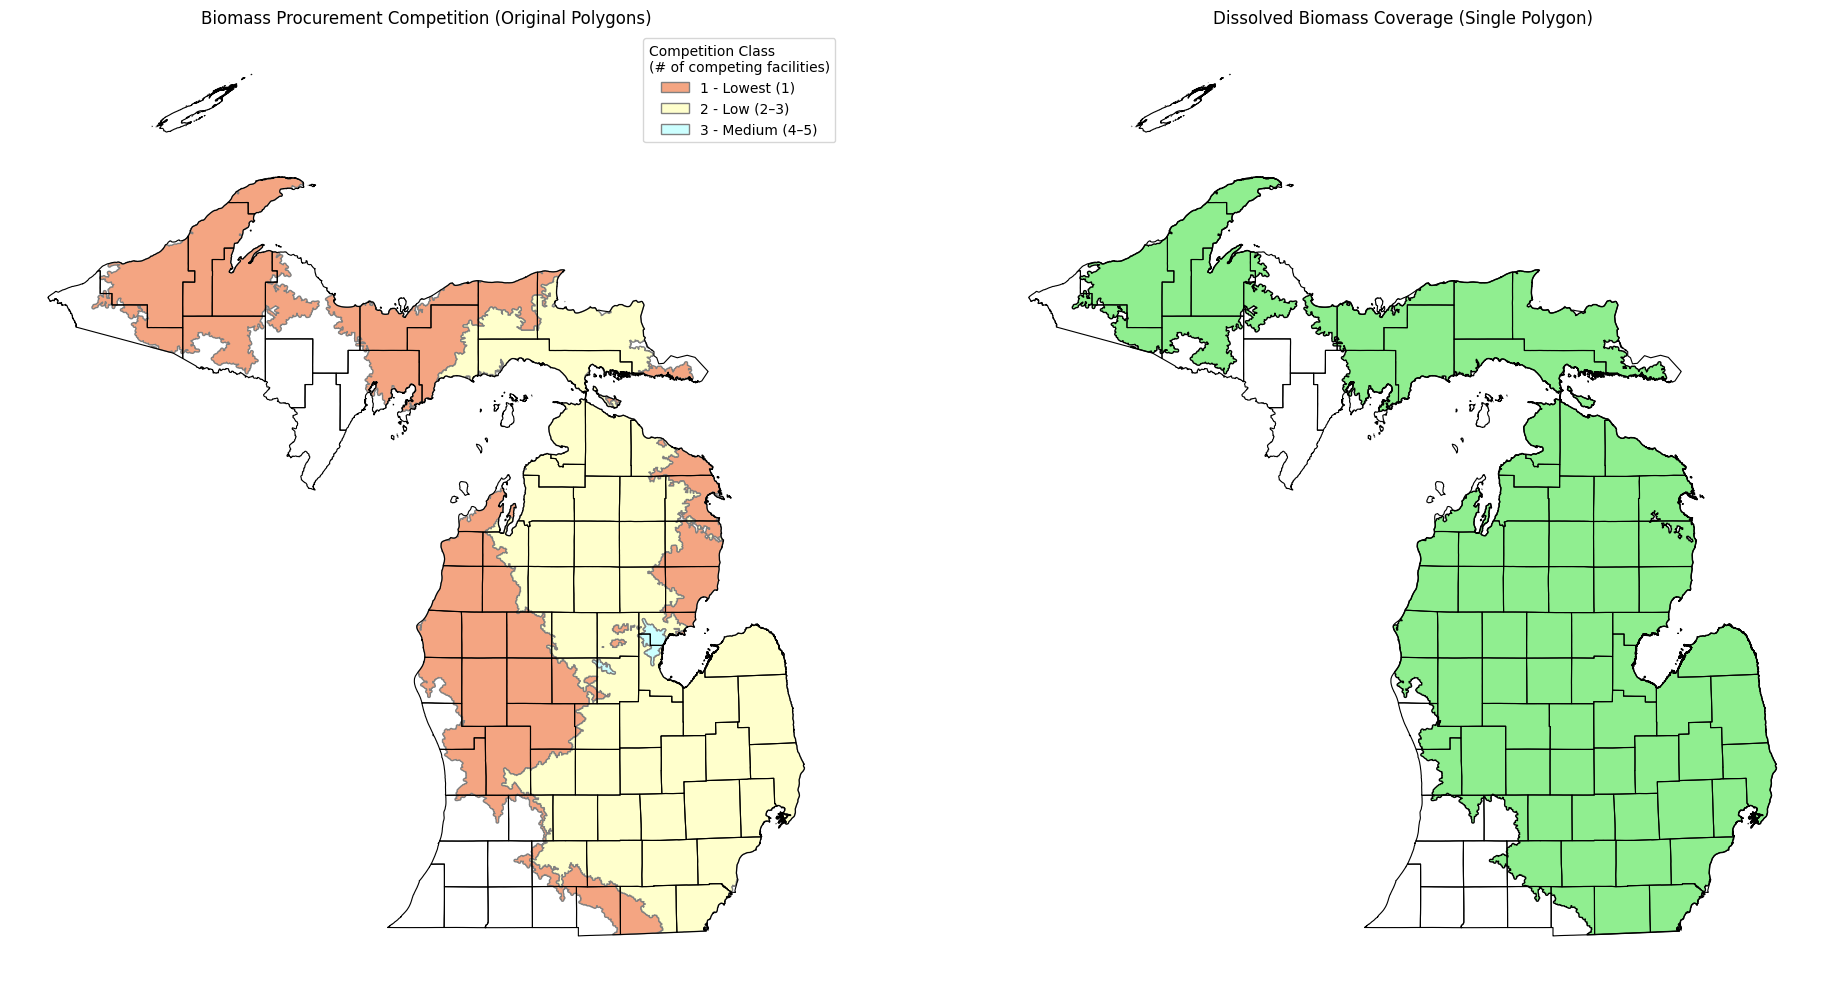

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Correct Colab base path ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

# --- Updated file paths ---
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
biomass_fp = os.path.join(base_path, "biomass_hotspots_2023.shp")
dissolved_fp = os.path.join(base_path, "biomass_coverage_2023.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_fp)
gdf_union = gpd.read_file(dissolved_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)
if gdf_union.crs != gdf_mi.crs:
    gdf_union = gdf_union.to_crs(gdf_mi.crs)

# --- Color map for classes ---
color_map = {
    "1 - Lowest (2023)": "#F4A582",
    "2 - Low (2023)": "#FFFFCC",
    "3 - Medium (2023)": "#CCFFFF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left subplot: Original biomass hotspots
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Biomass Procurement Competition (Original Polygons)")
axes[0].axis("off")

# Right subplot: Dissolved biomass coverage
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Biomass Coverage (Single Polygon)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_coverage_2018.shp


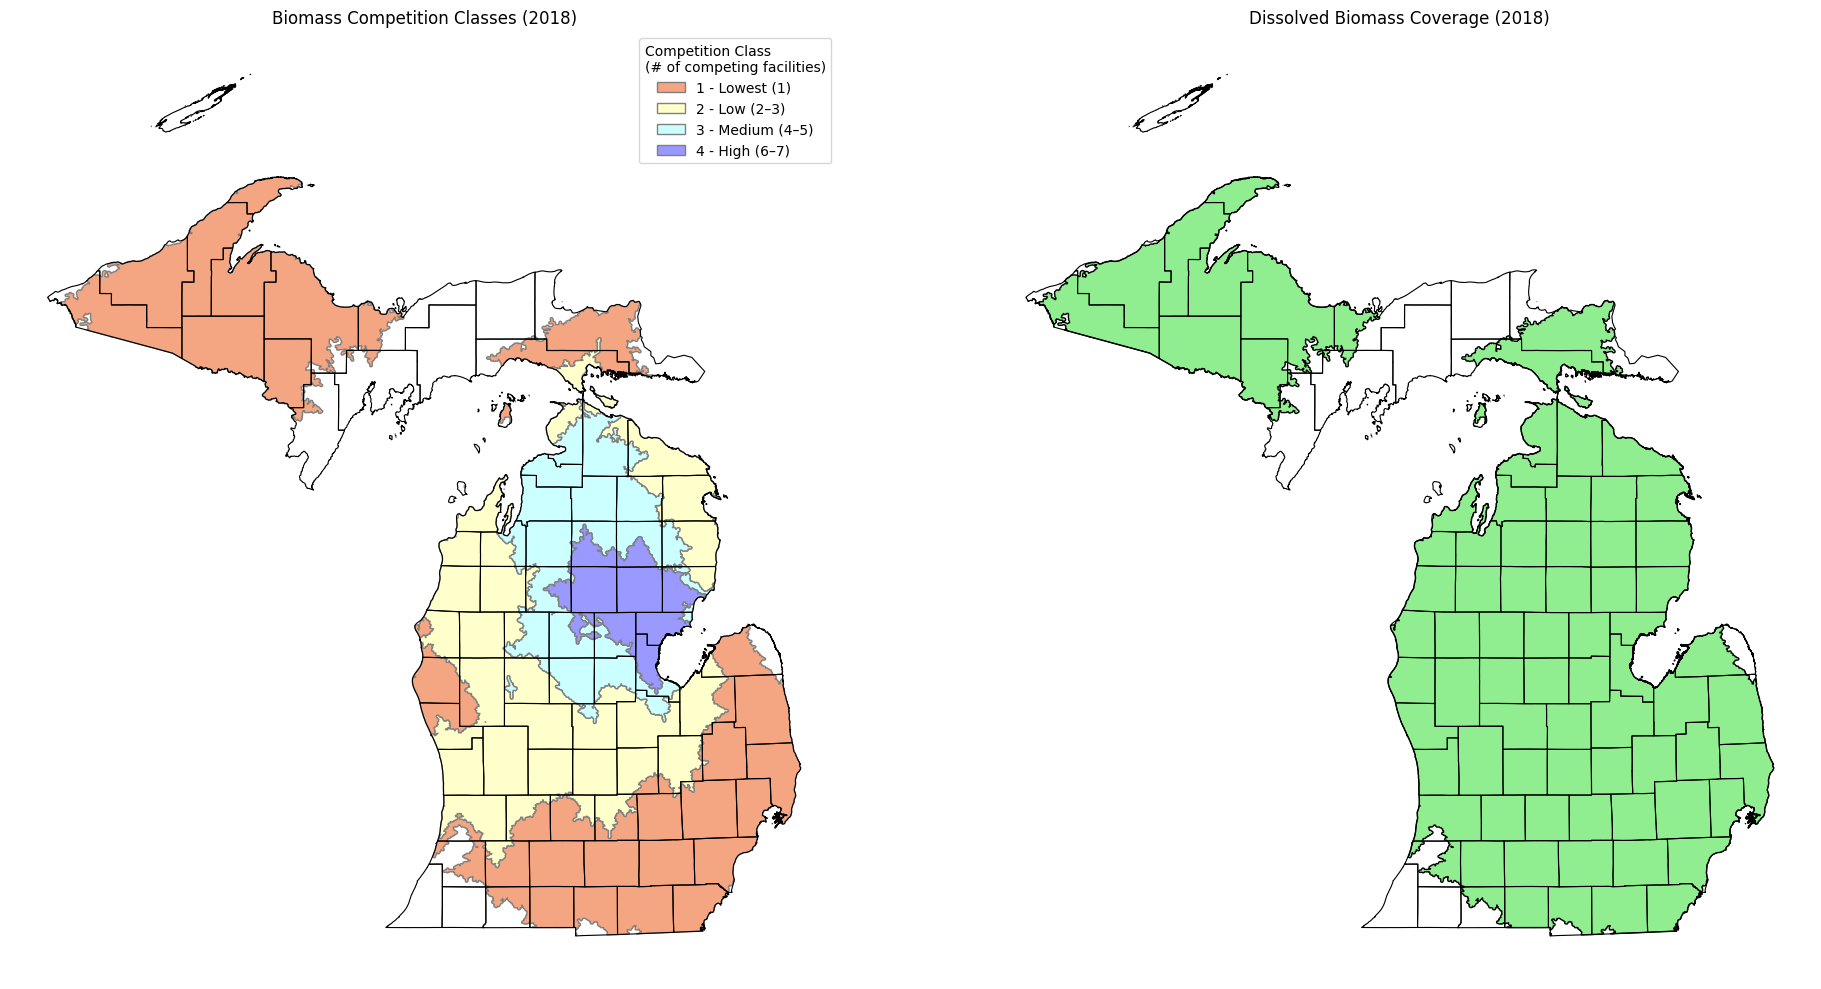

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Base path for Colab ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

# --- File paths ---
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
biomass_2018_fp = os.path.join(base_path, "biomass_hotspots_2018.shp")
dissolved_2018_fp = os.path.join(base_path, "biomass_coverage_2018.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_2018_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Dissolve into one polygon and save ---
gdf_union = gdf_bio.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2018_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2018_fp)

# --- Reload to confirm ---
gdf_union = gpd.read_file(dissolved_2018_fp)

# --- Color map (4 classes for 2018) ---
color_map = {
    "1 - Lowest (2018)": "#F4A582",
    "2 - Low (2018)": "#FFFFCC",
    "3 - Medium (2018)": "#CCFFFF",
    "4 - High (2018)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Biomass competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend for competition classes
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Biomass Competition Classes (2018)")
axes[0].axis("off")

# Right: Dissolved biomass polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Biomass Coverage (2018)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_coverage_2002.shp


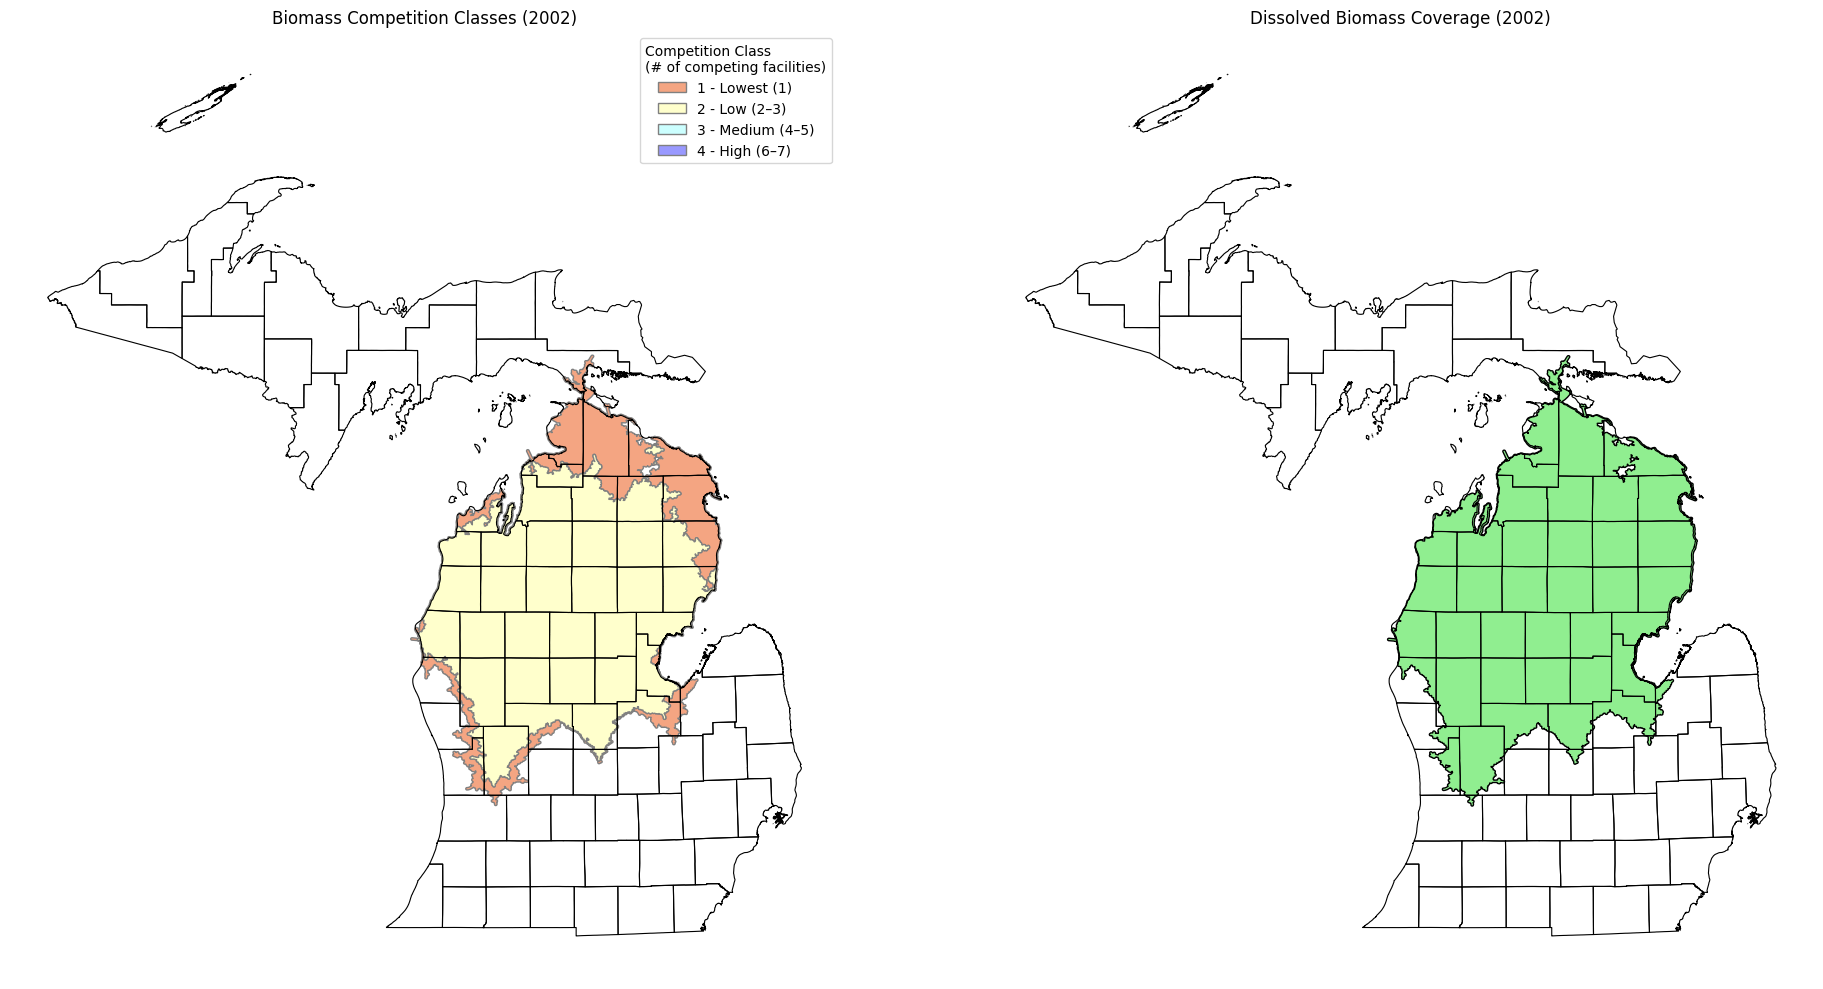

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Base path for Colab ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

# --- File paths ---
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
biomass_2002_fp = os.path.join(base_path, "biomass_hotspots_2002.shp")
dissolved_2002_fp = os.path.join(base_path, "biomass_coverage_2002.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_2002_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Dissolve into one polygon and save ---
gdf_union = gdf_bio.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2002_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2002_fp)

# --- Reload to confirm ---
gdf_union = gpd.read_file(dissolved_2002_fp)

# --- Color map (4 classes for 2002) ---
color_map = {
    "1 - Lowest (2002)": "#F4A582",
    "2 - Low (2002)": "#FFFFCC",
    "3 - Medium (2002)": "#CCFFFF",
    "4 - High (2002)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Biomass competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Biomass Competition Classes (2002)")
axes[0].axis("off")

# Right: Dissolved biomass polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Biomass Coverage (2002)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_coverage_1994.shp


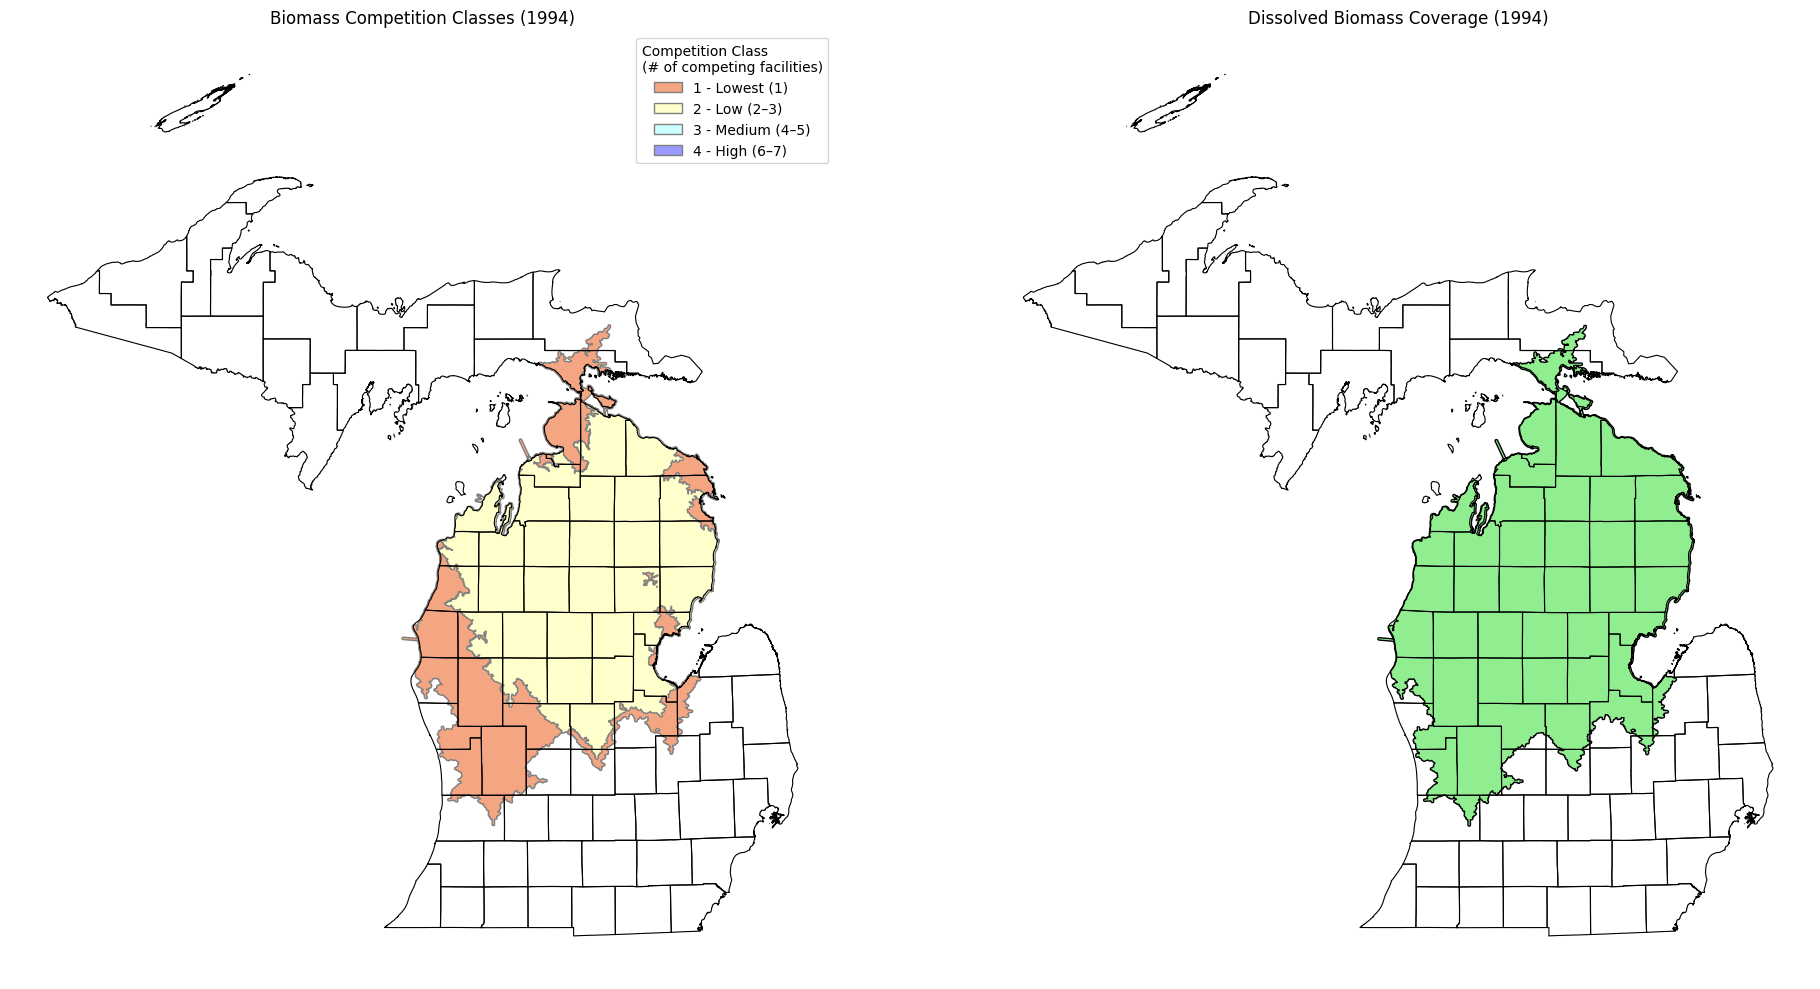

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Base path for Colab ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

# --- File paths ---
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
biomass_1994_fp = os.path.join(base_path, "biomass_hotspots_1994.shp")
dissolved_1994_fp = os.path.join(base_path, "biomass_coverage_1994.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_1994_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Dissolve into one polygon and save ---
gdf_union = gdf_bio.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1994_fp)
print("✅ Saved dissolved shapefile to:", dissolved_1994_fp)

# --- Reload to confirm ---
gdf_union = gpd.read_file(dissolved_1994_fp)

# --- Color map (4 classes for 1994) ---
color_map = {
    "1 - Lowest (1994)": "#F4A582",
    "2 - Low (1994)": "#FFFFCC",
    "3 - Medium (1994)": "#CCFFFF",
    "4 - High (1994)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Biomass competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend for competition classes
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Biomass Competition Classes (1994)")
axes[0].axis("off")

# Right: Dissolved biomass polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Biomass Coverage (1994)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_coverage_1985.shp


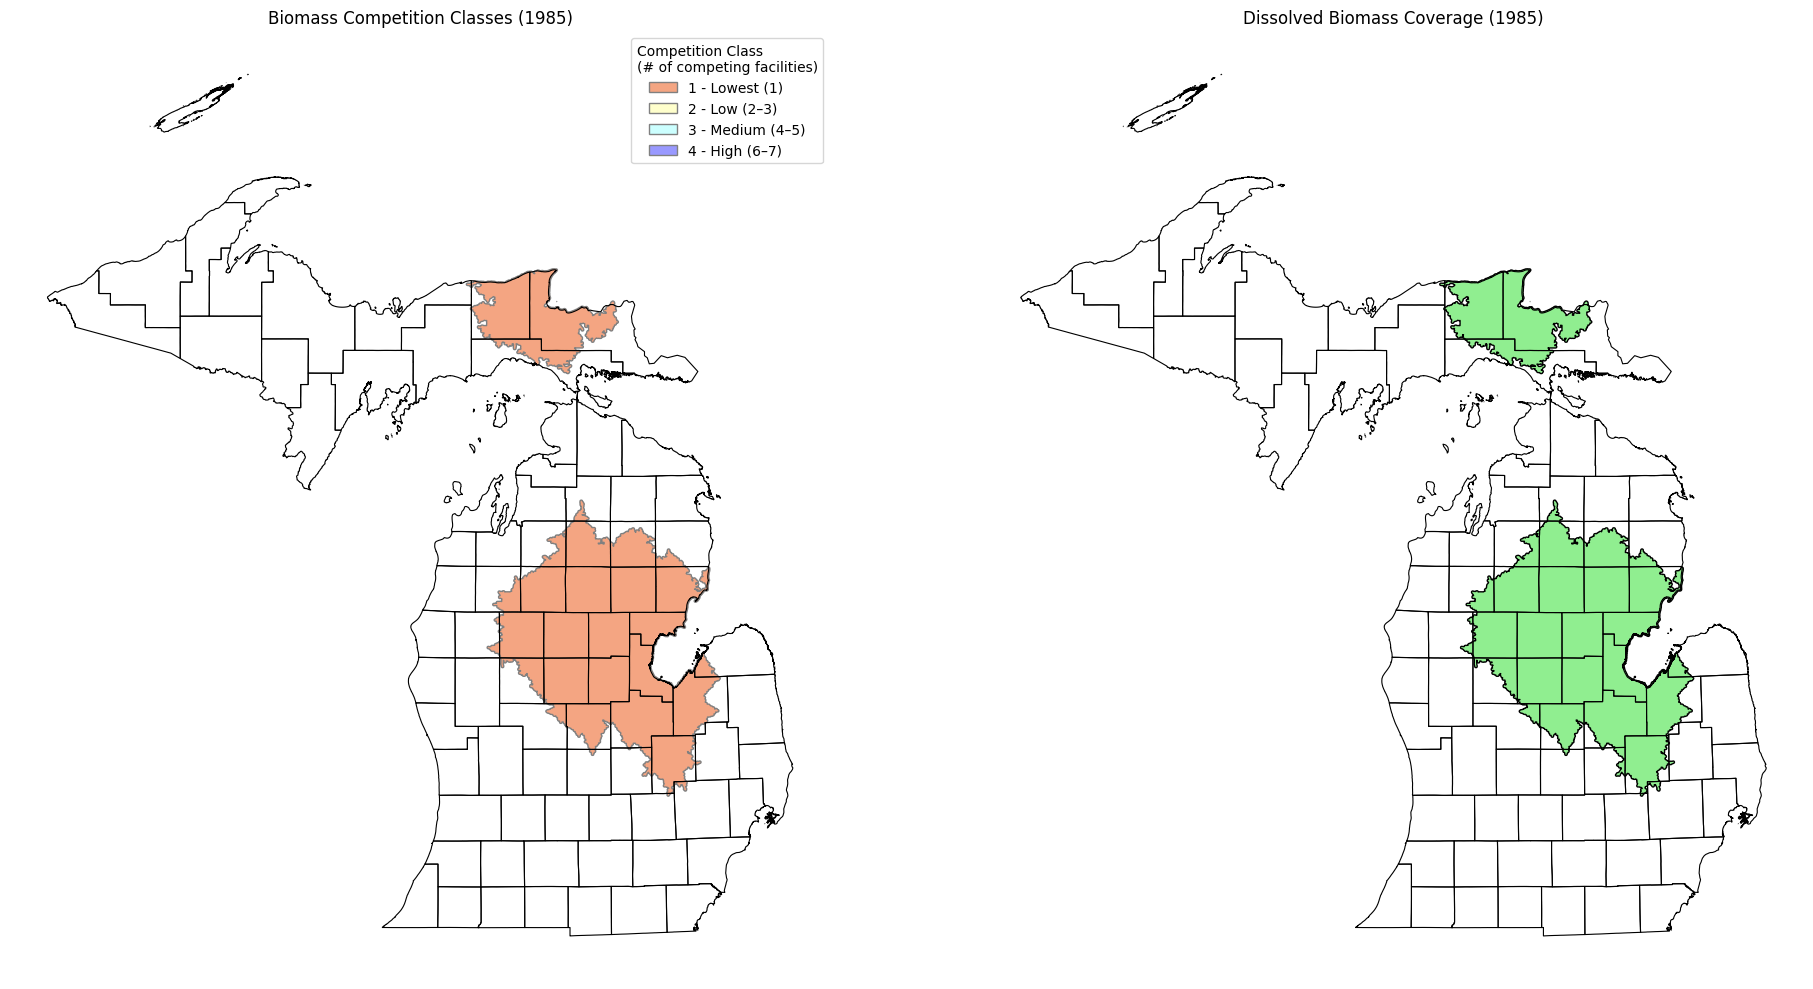

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Base path for Colab ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"

# --- File paths ---
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
biomass_1985_fp = os.path.join(base_path, "biomass_hotspots_1985.shp")
dissolved_1985_fp = os.path.join(base_path, "biomass_coverage_1985.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_bio = gpd.read_file(biomass_1985_fp)

# --- Reproject if needed ---
if gdf_bio.crs != gdf_mi.crs:
    gdf_bio = gdf_bio.to_crs(gdf_mi.crs)

# --- Dissolve into one polygon and save ---
gdf_union = gdf_bio.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1985_fp)
print("✅ Saved dissolved shapefile to:", dissolved_1985_fp)

# --- Reload to confirm ---
gdf_union = gpd.read_file(dissolved_1985_fp)

# --- Color map (4 classes for 1985) ---
color_map = {
    "1 - Lowest (1985)": "#F4A582",
    "2 - Low (1985)": "#FFFFCC",
    "3 - Medium (1985)": "#CCFFFF",
    "4 - High (1985)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Biomass competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_bio[gdf_bio["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Biomass Competition Classes (1985)")
axes[0].axis("off")

# Right: Dissolved biomass polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Biomass Coverage (1985)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


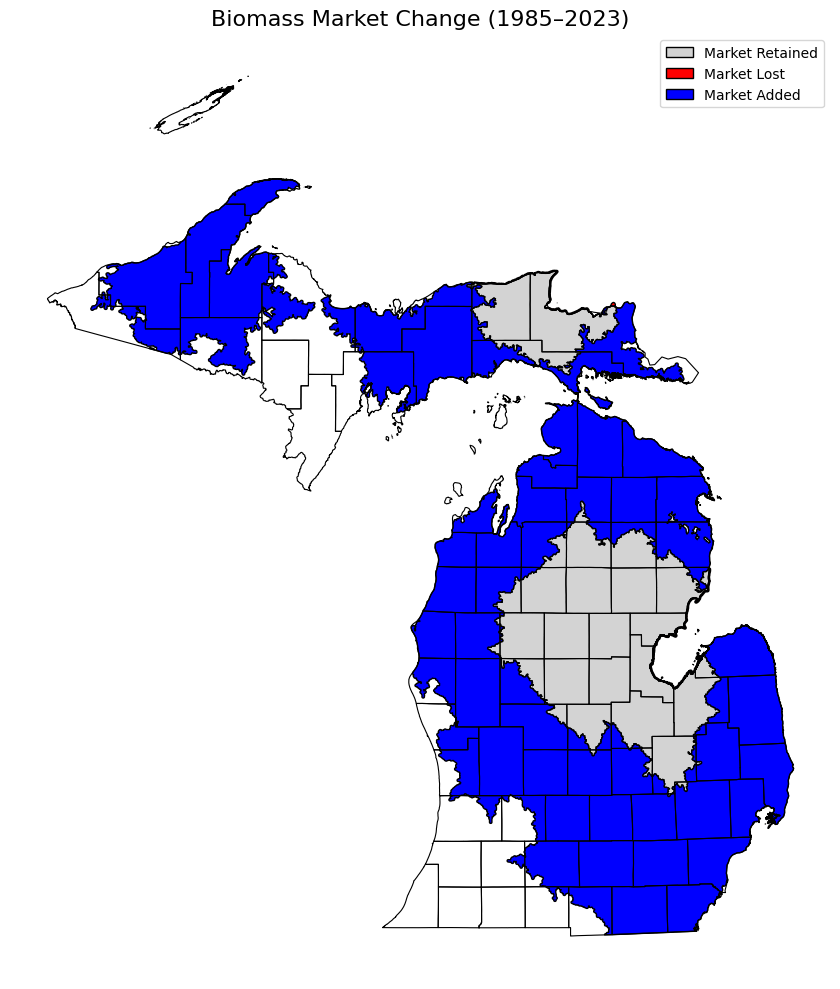

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths (Colab style) ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"
change_fp = os.path.join(base_path, "biomass_change_1985-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load shapefiles ---
gdf_change = gpd.read_file(change_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject county boundaries to match change data ---
if gdf_change.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_change.crs)

# --- Define color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each market status class
for label, color in color_map.items():
    subset = gdf_change[gdf_change["status"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black')

# --- Custom legend ---
legend_elements = [
    Patch(facecolor="#D3D3D3", edgecolor='black', label="Market Retained"),
    Patch(facecolor="#FF0000", edgecolor='black', label="Market Lost"),
    Patch(facecolor="#0000FF", edgecolor='black', label="Market Added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# --- Final touches ---
ax.set_title("Biomass Market Change (1985–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ Local file paths
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
raster_path = os.path.join(base_path, "lulc2001.tif")
shapefile_path = os.path.join(base_path, "biomass_change_1985-2023.shp")

# ✅ Forest land cover class codes
forest_values = [31, 41, 42, 43, 52, 71, 81, 95]  # Modify if needed

# ✅ Open raster
with rasterio.open(raster_path) as src:
    pixel_area_acres = (src.res[0] * abs(src.res[1])) * 0.000247105  # m² to acres
    nodata = src.nodata
    raster_crs = src.crs

    # ✅ Open shapefile
    with fiona.open(shapefile_path, 'r') as shp:
        shp_crs = shp.crs

        # Function to reproject geometries if needed
        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        # ✅ Loop through features
        for feature in shp:
            polygon_label = feature["properties"].get("status", "unknown")  # Column name is 'status'
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon '{polygon_label}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            data = out_image[0]
            forest_mask = np.isin(data, forest_values) & (data != nodata) if nodata is not None else np.isin(data, forest_values)
            forest_area_acres = np.sum(forest_mask) * pixel_area_acres

            print(f"Polygon '{polygon_label}' has a forest area of {forest_area_acres:,.2f} acres.")


Polygon 'Market Retain' has a forest area of 3,103,479.89 acres.
Polygon 'Market Loss' has a forest area of 8.90 acres.
Polygon 'Market Add' has a forest area of 9,871,837.21 acres.


In [ ]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj

# ✅ Colab paths
# ✅ File paths for biomass change 1985–2023
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
shapefile_path = os.path.join(base_path, "biomass_change_1985-2023.shp")

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Open and process raster and shapefile
with rasterio.open(raster_path) as src:
    pixel_width = src.transform[0]
    pixel_height = abs(src.transform[4])
    pixel_area_sq_m = pixel_width * pixel_height
    pixel_area_acres = pixel_area_sq_m * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            project = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(project, shape(geom)))

        for feature in shapefile:
            polygon_label = feature["properties"].get("status", "unknown")

            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, out_transform = mask(src, [geom], crop=True)
            except ValueError as e:
                if "do not overlap" in str(e):
                    print(f"Polygon '{polygon_label}' does not overlap the raster. Skipping...")
                    continue
                else:
                    raise

            out_data = out_image[0]

            if nodata is not None:
                valid_data = out_data[out_data != nodata]
            else:
                valid_data = out_data

            unique_types, pixel_counts = np.unique(valid_data, return_counts=True)

            forest_type_areas_acres = {
                forest_type_mapping.get(forest_type): count * pixel_area_acres
                for forest_type, count in zip(unique_types, pixel_counts)
                if forest_type_mapping.get(forest_type) is not None
            }

            total_area_acres = sum(forest_type_areas_acres.values())

            print(f"Polygon '{polygon_label}' has a forest area of {total_area_acres:.2f} acres.")
            for forest_type, area in forest_type_areas_acres.items():
                print(f"   {forest_type}: {area:.2f} acres")
            print()


Polygon 'Market Retain' has a forest area of 4031101.09 acres.
   White/Red/Jack Pine Group: 891832.83 acres
   Spruce/Fir Group: 643399.64 acres
   Oak/Hickory Group: 1034.75 acres
   Elm/Ash/Cottonwood Group: 231.66 acres
   Maple/Beech/Birch Group: 92.66 acres
   Aspen/Birch Group: 2494509.53 acres

Polygon 'Market Loss' has a forest area of 108.11 acres.
   White/Red/Jack Pine Group: 108.11 acres

Polygon 'Market Add' has a forest area of 11087369.69 acres.
   White/Red/Jack Pine Group: 1366320.77 acres
   Spruce/Fir Group: 1702429.90 acres
   Exotic Softwoods Group: 139.00 acres
   Oak/Hickory Group: 29915.15 acres
   Elm/Ash/Cottonwood Group: 40617.88 acres
   Maple/Beech/Birch Group: 2582293.58 acres
   Aspen/Birch Group: 5365653.41 acres



/tmp/ipython-input-20-3516812048.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1994 = gdf_1994.unary_union
/tmp/ipython-input-20-3516812048.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_change_1994-2023.shp


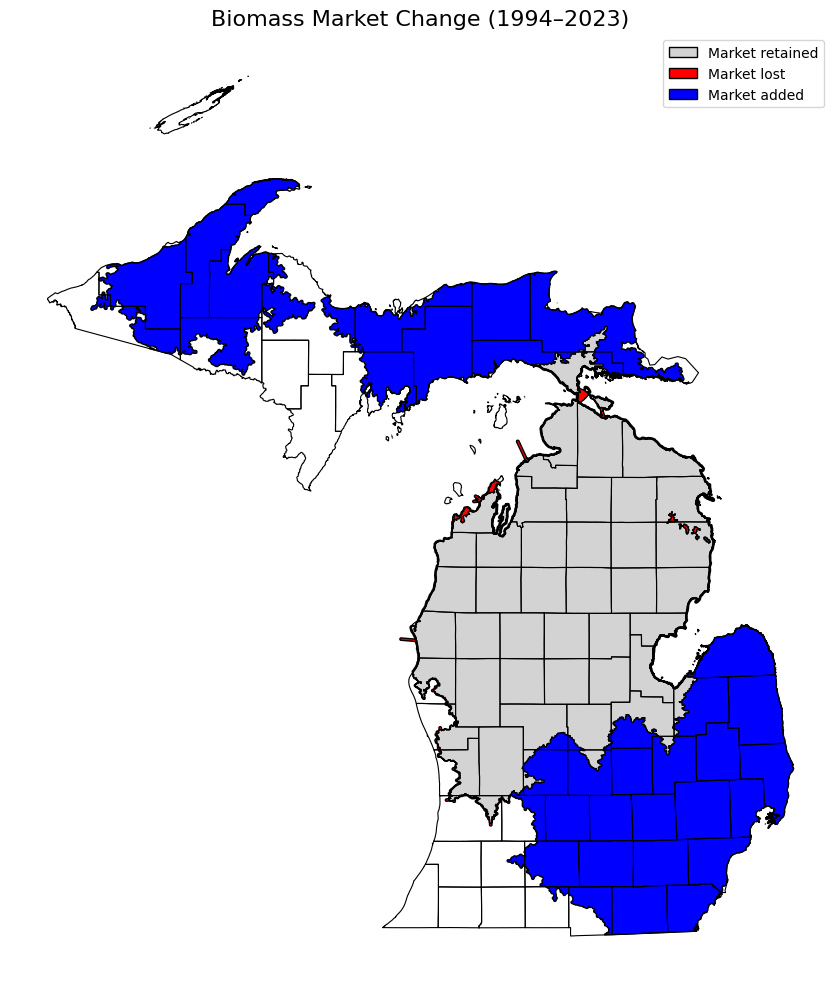

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1994_fp = os.path.join(base_path, "biomass_coverage_1994.shp")
coverage_2023_fp = os.path.join(base_path, "biomass_coverage_2023.shp")
change_fp = os.path.join(base_path, "biomass_change_1994-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_1994 = gpd.read_file(coverage_1994_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1994.crs)
if gdf_1994.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1994.crs)

# --- Geometry union ---
geom_1994 = gdf_1994.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate changes ---
retain = geom_1994.intersection(geom_2023)
loss = geom_1994.difference(geom_2023)
add = geom_2023.difference(geom_1994)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1994.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Biomass Market Change (1994–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


/tmp/ipython-input-21-328837305.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2002 = gdf_2002.unary_union
/tmp/ipython-input-21-328837305.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_change_2002-2023.shp


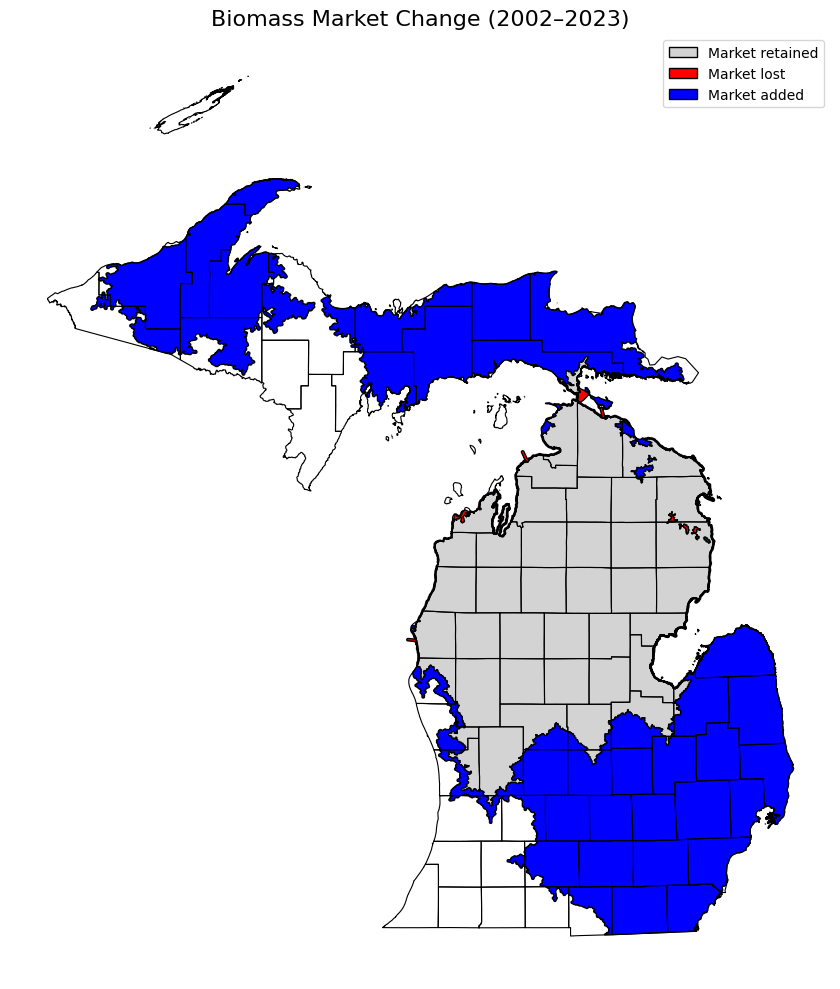

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths (within Colab-extracted folder) ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"
coverage_2002_fp = os.path.join(base_path, "biomass_coverage_2002.shp")
coverage_2023_fp = os.path.join(base_path, "biomass_coverage_2023.shp")
change_fp = os.path.join(base_path, "biomass_change_2002-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load shapefiles ---
gdf_2002 = gpd.read_file(coverage_2002_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2002.crs)
if gdf_2002.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2002.crs)

# --- Union geometries
geom_2002 = gdf_2002.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate market change geometries
retain = geom_2002.intersection(geom_2023)
loss = geom_2002.difference(geom_2023)
add = geom_2023.difference(geom_2002)

# --- Construct change GeoDataFrame
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2002.crs)

# --- Save to file
gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Define colors
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot change map
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Add legend
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Biomass Market Change (2002–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


/tmp/ipython-input-22-145032230.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2018 = gdf_2018.unary_union
/tmp/ipython-input-22-145032230.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: /content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/biomass_change_2018-2023.shp


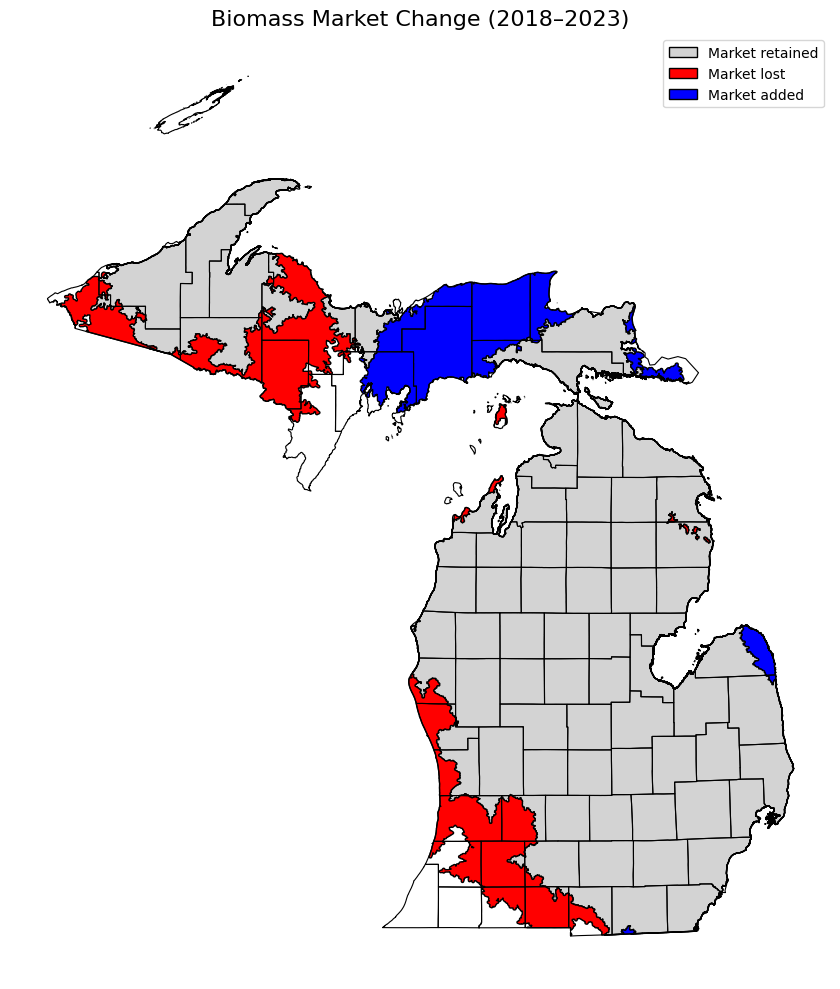

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"
coverage_2018_fp = os.path.join(base_path, "biomass_coverage_2018.shp")
coverage_2023_fp = os.path.join(base_path, "biomass_coverage_2023.shp")
change_fp = os.path.join(base_path, "biomass_change_2018-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_2018 = gpd.read_file(coverage_2018_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2018.crs)
if gdf_2018.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2018.crs)

# --- Union geometries ---
geom_2018 = gdf_2018.unary_union
geom_2023 = gdf_2023.unary_union

# --- Market change geometry math ---
retain = geom_2018.intersection(geom_2023)
loss = geom_2018.difference(geom_2023)
add = geom_2023.difference(geom_2018)

# --- Build output shapefile ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2018.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot results ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend and title ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Biomass Market Change (2018–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


# Pulpwood

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ✅ Colab base path
base_path = "Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
pulpwood_1985_fp = os.path.join(base_path, "pulpwood_hotspots_1985.shp")
dissolved_pulpwood_fp = os.path.join(base_path, "pulpwood_coverage_1985.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_pulp = gpd.read_file(pulpwood_1985_fp)

# --- Reproject if needed ---
if gdf_pulp.crs != gdf_mi.crs:
    gdf_pulp = gdf_pulp.to_crs(gdf_mi.crs)

# --- Dissolve polygons and save as single coverage shapefile ---
gdf_union = gdf_pulp.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_pulpwood_fp)
print("✅ Saved dissolved shapefile to:", dissolved_pulpwood_fp)

# --- Reload dissolved file for plotting ---
gdf_union = gpd.read_file(dissolved_pulpwood_fp)

# --- Color map for pulpwood competition ---
color_map = {
    "1 - Lowest (1985)": "#F4A582",
    "2 - Low (1985)": "#FFFFCC",
    "3 - Medium (1985)": "#CCFFFF",
    "4 - High (1985)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left panel: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_pulp[gdf_pulp["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Pulpwood Competition Classes (1985)")
axes[0].axis("off")

# Right panel: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Pulpwood Coverage (1985)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


DataSourceError: Khanal_MSc_Thesis_MSU-main/Khanal_MSU_project_new_forest_area_1980s-2020s/Data/Counties_(v17a).shp: No such file or directory

✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_coverage_1994.shp


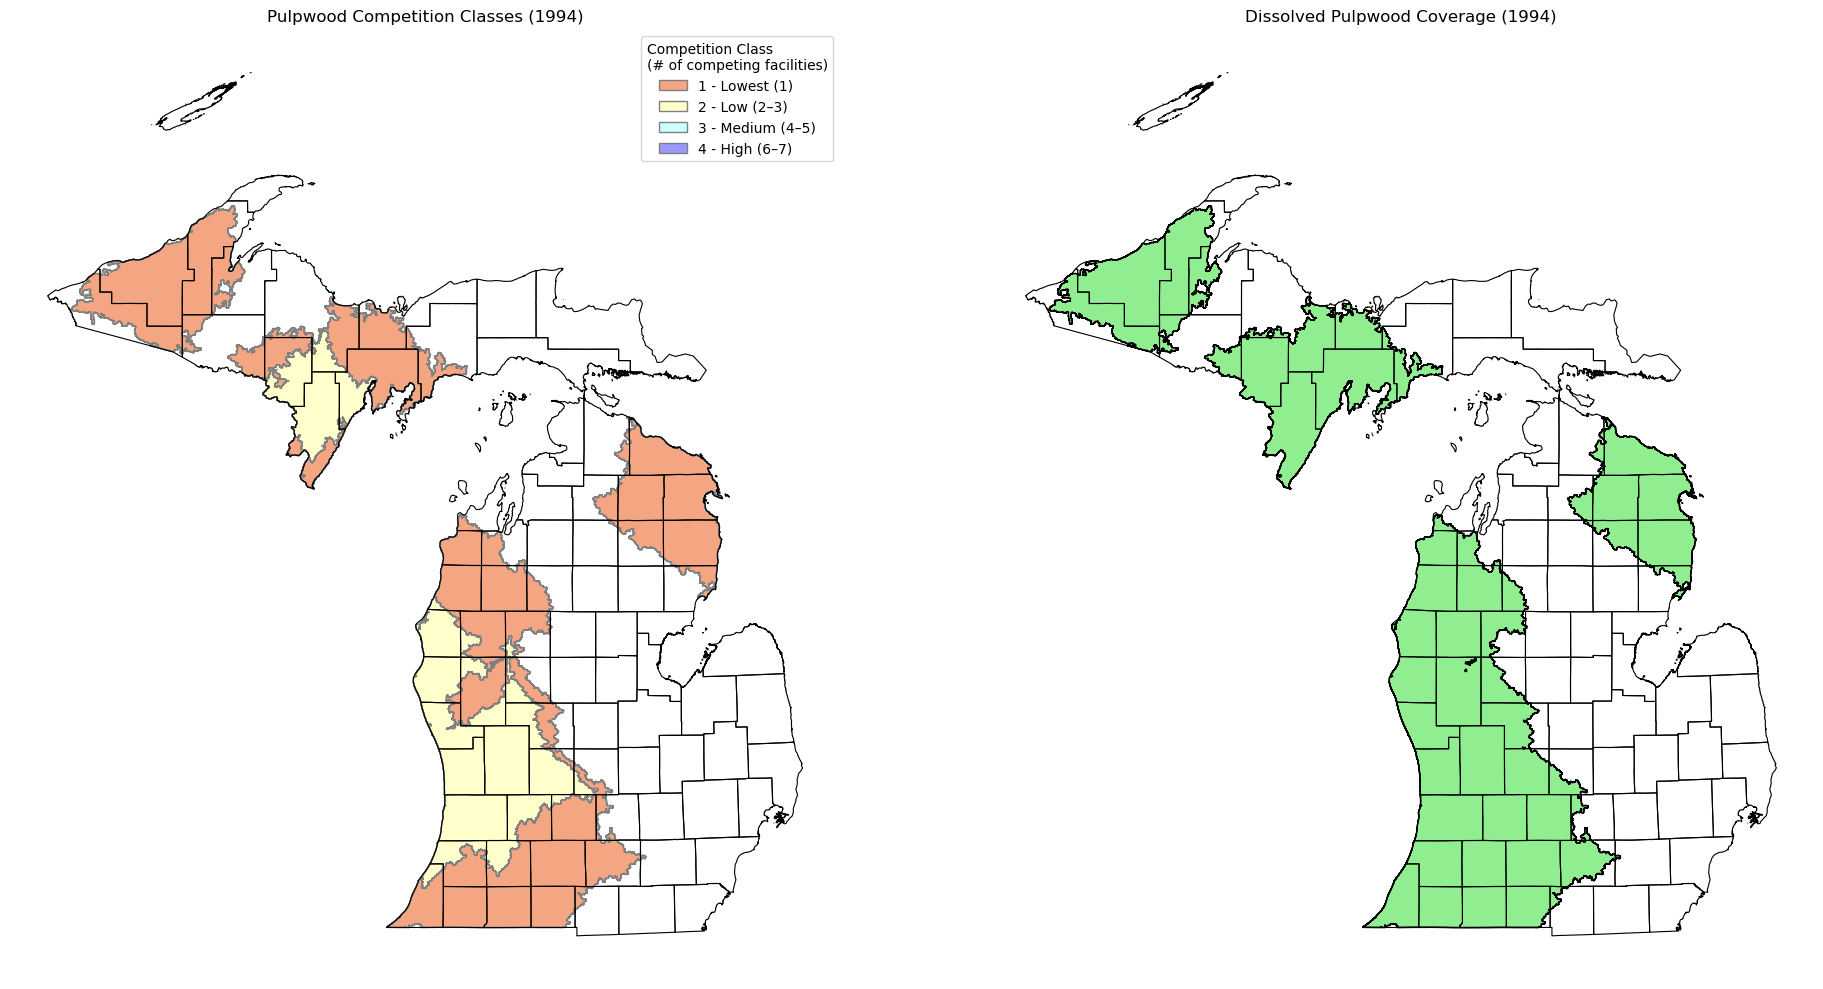

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
pulpwood_1994_fp = os.path.join(base_path, "pulpwood_hotspots_1994.shp")
dissolved_pulpwood_fp = os.path.join(base_path, "pulpwood_coverage_1994.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_pulp = gpd.read_file(pulpwood_1994_fp)

# --- Reproject if needed ---
if gdf_pulp.crs != gdf_mi.crs:
    gdf_pulp = gdf_pulp.to_crs(gdf_mi.crs)

# --- Dissolve polygons and save ---
gdf_union = gdf_pulp.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_pulpwood_fp)
print("✅ Saved dissolved shapefile to:", dissolved_pulpwood_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_pulpwood_fp)

# --- Color map for pulpwood competition classes ---
color_map = {
    "1 - Lowest (1994)": "#F4A582",
    "2 - Low (1994)": "#FFFFCC",
    "3 - Medium (1994)": "#CCFFFF",
    "4 - High (1994)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# === Left: Original classified polygons ===
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_pulp[gdf_pulp["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Pulpwood Competition Classes (1994)")
axes[0].axis("off")

# === Right: Dissolved polygon ===
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Pulpwood Coverage (1994)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_coverage_2002.shp


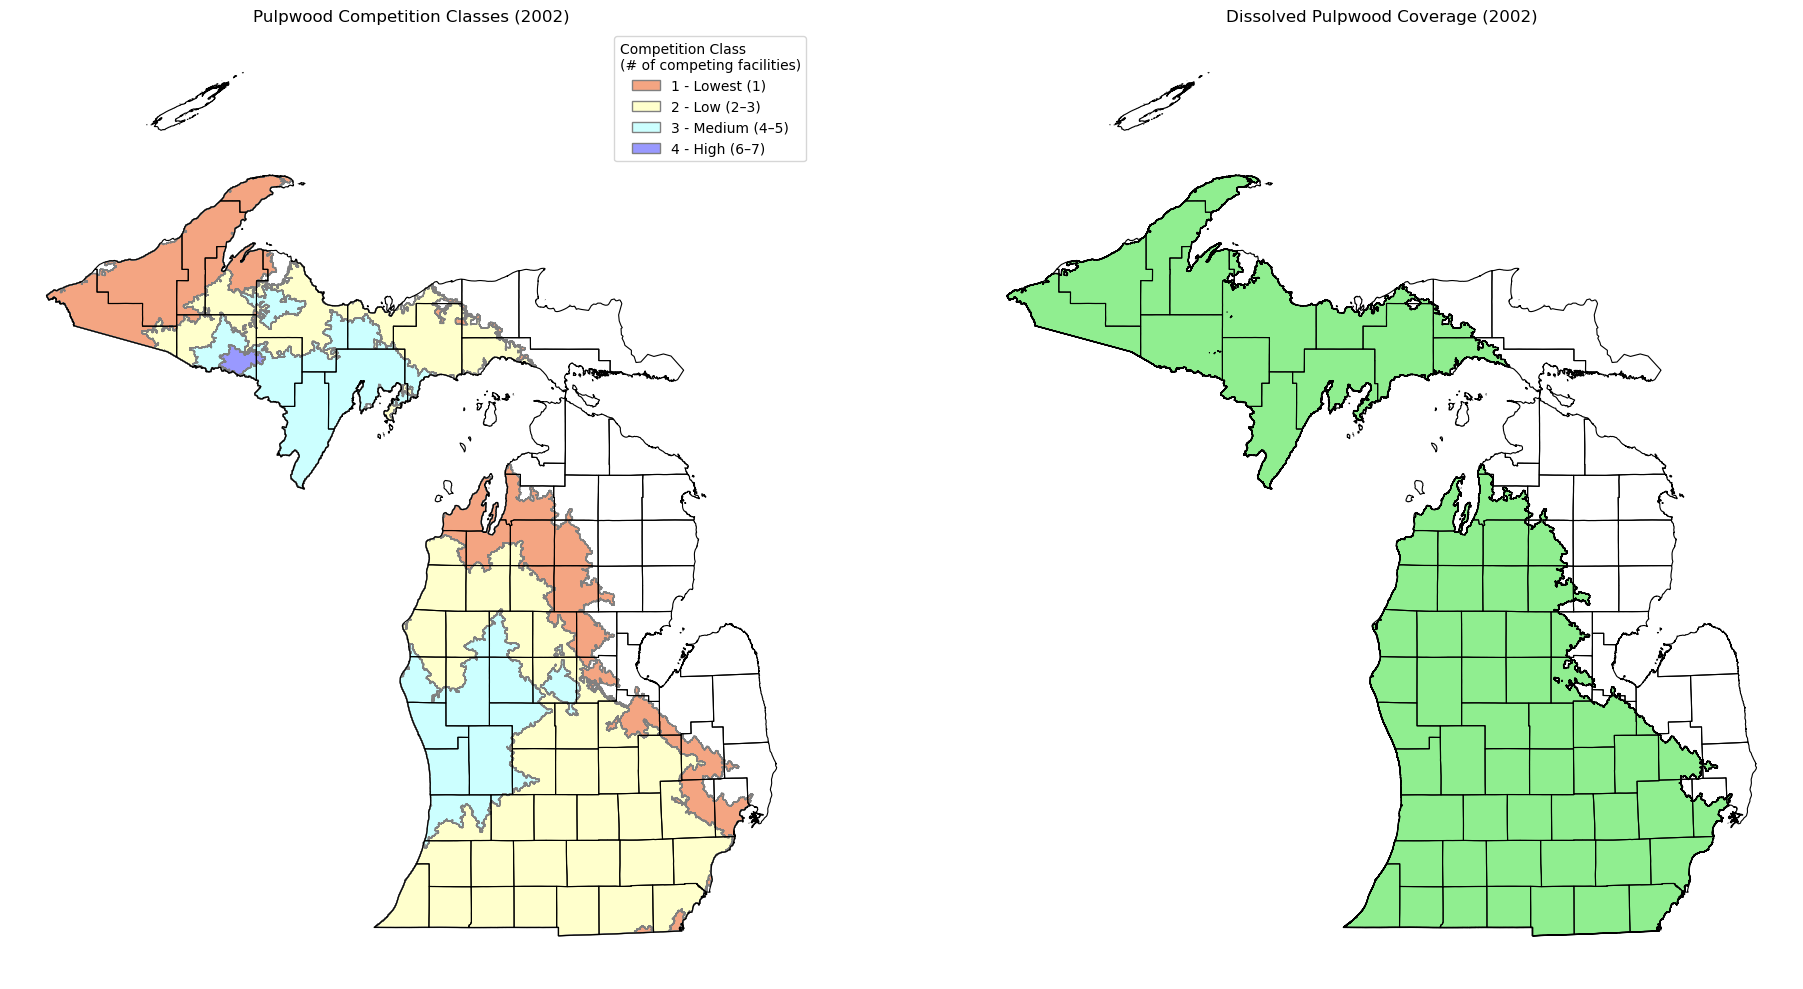

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
pulpwood_2002_fp = os.path.join(base_path, "pulpwood_hotspots_2002.shp")
dissolved_pulpwood_fp = os.path.join(base_path, "pulpwood_coverage_2002.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_pulp = gpd.read_file(pulpwood_2002_fp)

# --- Reproject if needed ---
if gdf_pulp.crs != gdf_mi.crs:
    gdf_pulp = gdf_pulp.to_crs(gdf_mi.crs)

# --- Dissolve polygons and save ---
gdf_union = gdf_pulp.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_pulpwood_fp)
print("✅ Saved dissolved shapefile to:", dissolved_pulpwood_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_pulpwood_fp)

# --- Color map for pulpwood competition classes ---
color_map = {
    "1 - Lowest (2002)": "#F4A582",
    "2 - Low (2002)": "#FFFFCC",
    "3 - Medium (2002)": "#CCFFFF",
    "4 - High (2002)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# === Left: Original classified polygons ===
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_pulp[gdf_pulp["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Pulpwood Competition Classes (2002)")
axes[0].axis("off")

# === Right: Dissolved polygon ===
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Pulpwood Coverage (2002)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_coverage_2018.shp


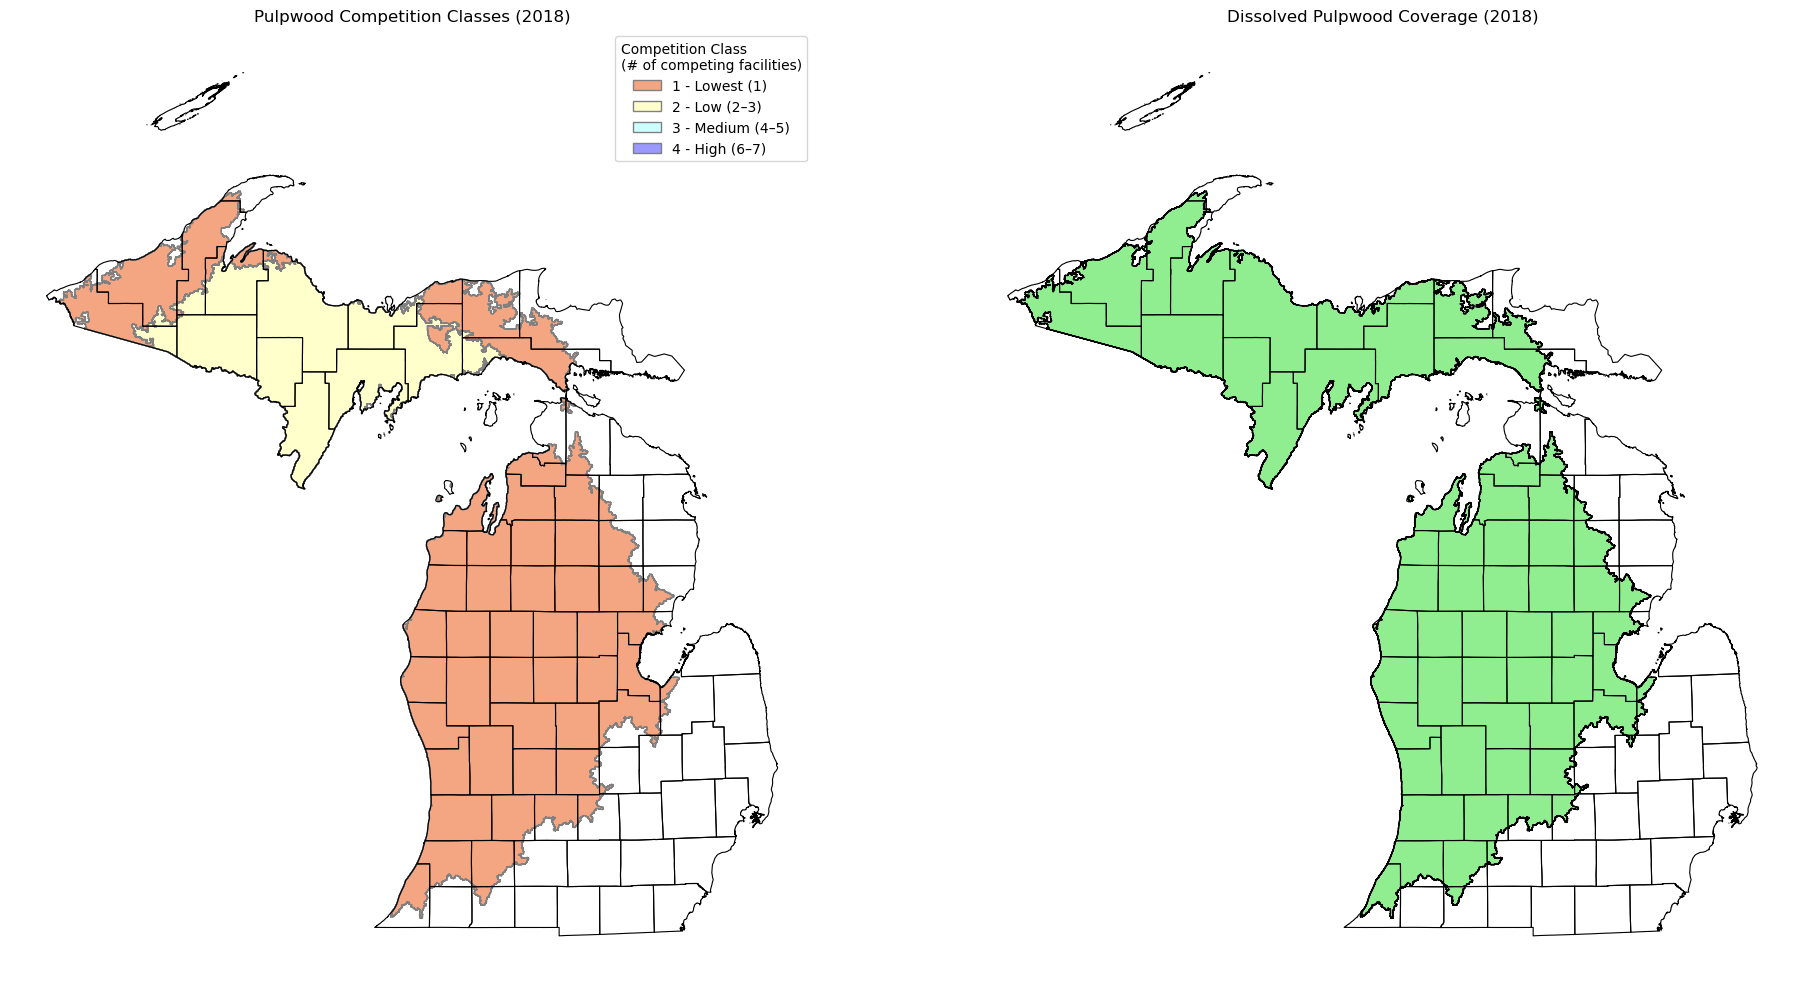

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
pulpwood_2018_fp = os.path.join(base_path, "pulpwood_hotspots_2018.shp")
dissolved_pulpwood_fp = os.path.join(base_path, "pulpwood_coverage_2018.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_pulp = gpd.read_file(pulpwood_2018_fp)

# --- Reproject if needed ---
if gdf_pulp.crs != gdf_mi.crs:
    gdf_pulp = gdf_pulp.to_crs(gdf_mi.crs)

# --- Dissolve polygons and save ---
gdf_union = gdf_pulp.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_pulpwood_fp)
print("✅ Saved dissolved shapefile to:", dissolved_pulpwood_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_pulpwood_fp)

# --- Color map for pulpwood competition classes ---
color_map = {
    "1 - Lowest (2018)": "#F4A582",
    "2 - Low (2018)": "#FFFFCC",
    "3 - Medium (2018)": "#CCFFFF",
    "4 - High (2018)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# === Left: Original classified polygons ===
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_pulp[gdf_pulp["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Pulpwood Competition Classes (2018)")
axes[0].axis("off")

# === Right: Dissolved polygon ===
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Pulpwood Coverage (2018)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_coverage_2023.shp


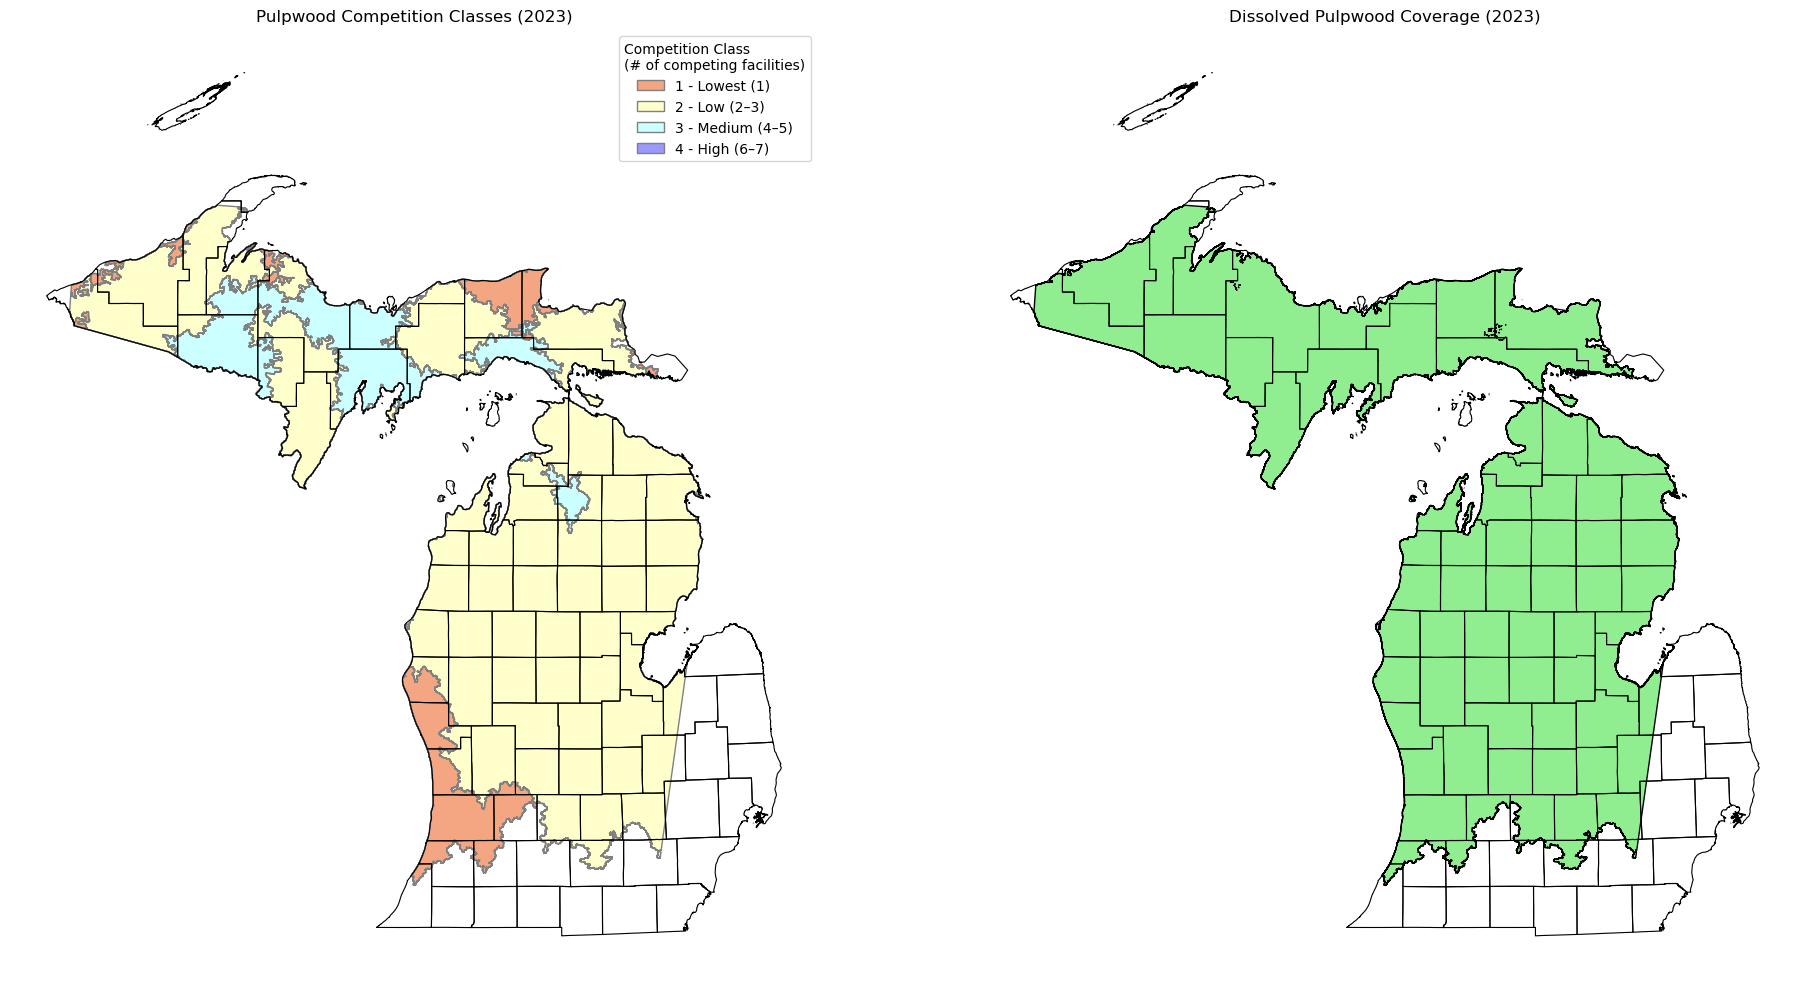

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
pulpwood_2023_fp = os.path.join(base_path, "pulpwood_hotspots_2023.shp")
dissolved_pulpwood_fp = os.path.join(base_path, "pulpwood_coverage_2023.shp")

# --- Load data ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_pulp = gpd.read_file(pulpwood_2023_fp)

# --- Reproject if needed ---
if gdf_pulp.crs != gdf_mi.crs:
    gdf_pulp = gdf_pulp.to_crs(gdf_mi.crs)

# --- Dissolve polygons and save ---
gdf_union = gdf_pulp.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_pulpwood_fp)
print("✅ Saved dissolved shapefile to:", dissolved_pulpwood_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_pulpwood_fp)

# --- Color map for pulpwood competition classes ---
color_map = {
    "1 - Lowest (2023)": "#F4A582",
    "2 - Low (2023)": "#FFFFCC",
    "3 - Medium (2023)": "#CCFFFF",
    "4 - High (2023)": "#9999FF"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# === Left: Original classified polygons ===
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_pulp[gdf_pulp["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

# Legend
legend_elements = [
    Patch(facecolor="#F4A582", edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor="#FFFFCC", edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor="#CCFFFF", edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor="#9999FF", edgecolor='grey', label="4 - High (6–7)")
]
axes[0].legend(handles=legend_elements,
               title="Competition Class\n(# of competing facilities)",
               loc='upper right', frameon=True)
axes[0].set_title("Pulpwood Competition Classes (2023)")
axes[0].axis("off")

# === Right: Dissolved polygon ===
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Pulpwood Coverage (2023)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\2845533535.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1985 = gdf_1985.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\2845533535.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_change_1985-2023.shp


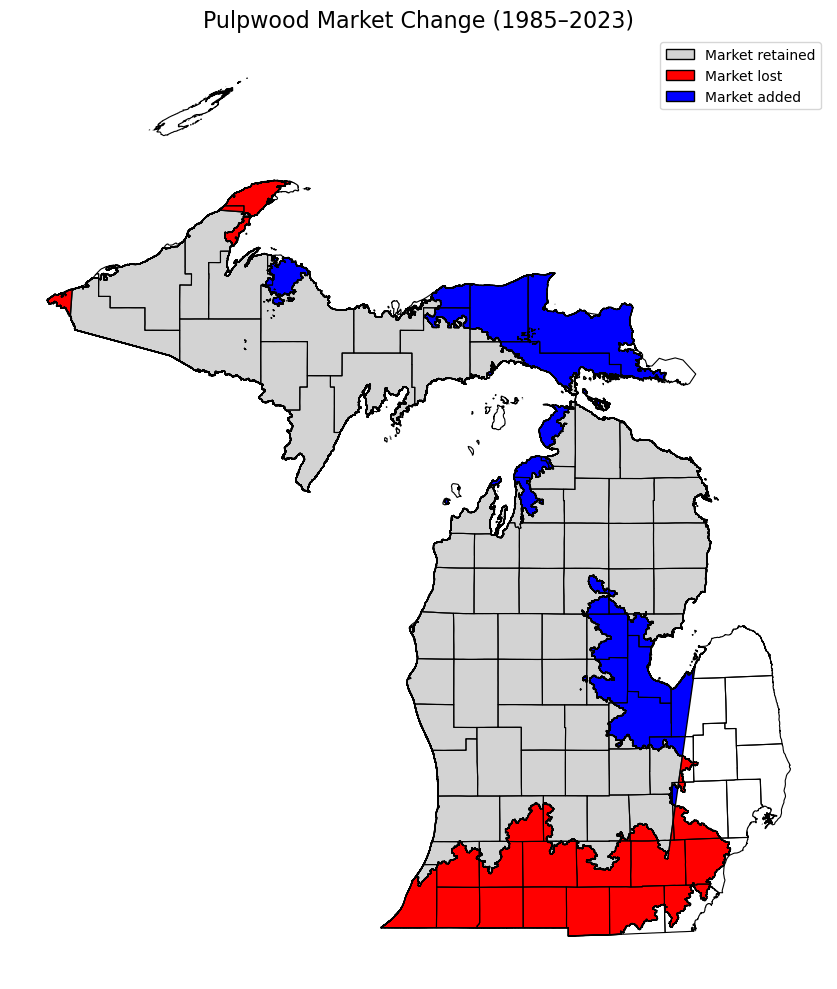

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1985_fp = os.path.join(base_path, "pulpwood_coverage_1985.shp")
coverage_2023_fp = os.path.join(base_path, "pulpwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "pulpwood_change_1985-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_1985 = gpd.read_file(coverage_1985_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1985.crs)
if gdf_1985.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1985.crs)

# --- Geometry union ---
geom_1985 = gdf_1985.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types ---
retain = geom_1985.intersection(geom_2023)
loss = geom_1985.difference(geom_2023)
add = geom_2023.difference(geom_1985)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1985.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Pulpwood Market Change (1985–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1939457959.py:41: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1994 = gdf_1994.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1939457959.py:42: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_change_1994-2023.shp


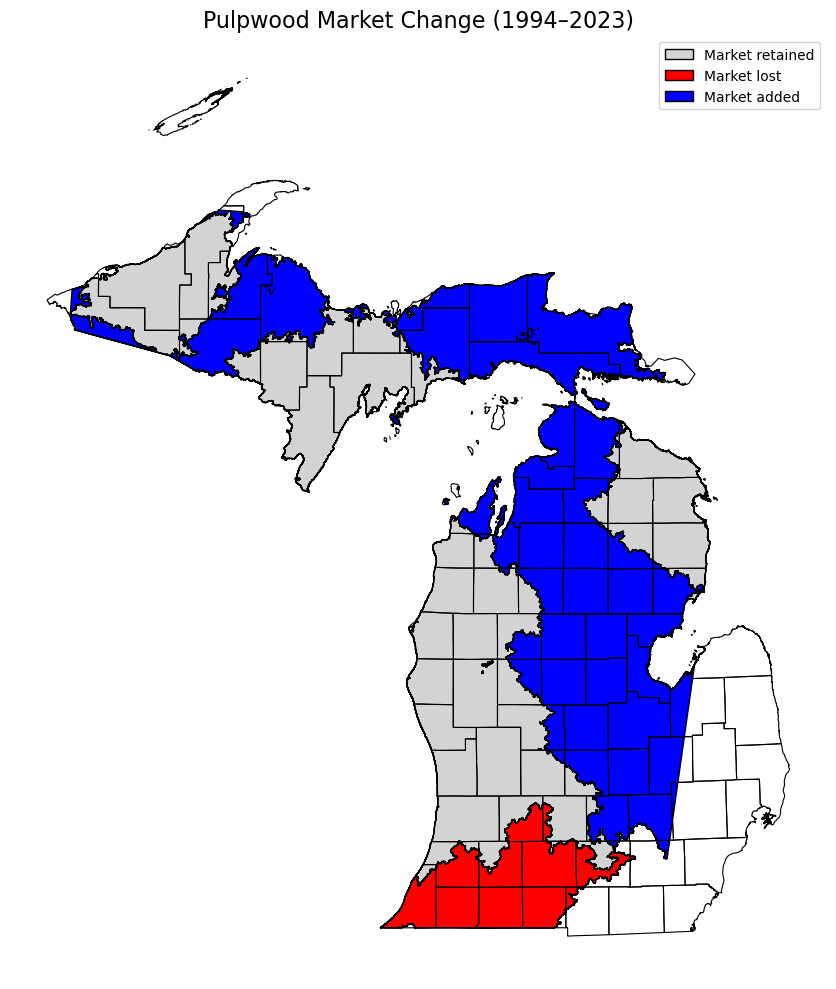

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
from shapely.geometry import GeometryCollection, MultiPolygon, Polygon

# --- Helper function to sanitize geometry ---
def flatten_geometry(geom):
    if geom.is_empty:
        return None
    elif isinstance(geom, (Polygon, MultiPolygon)):
        return geom
    elif isinstance(geom, GeometryCollection):
        # Extract only Polygon or MultiPolygon parts
        polys = [g for g in geom.geoms if isinstance(g, (Polygon, MultiPolygon))]
        if not polys:
            return None
        return MultiPolygon(polys) if len(polys) > 1 else polys[0]
    else:
        return None

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1994_fp = os.path.join(base_path, "pulpwood_coverage_1994.shp")
coverage_2023_fp = os.path.join(base_path, "pulpwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "pulpwood_change_1994-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_1994 = gpd.read_file(coverage_1994_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1994.crs)
if gdf_1994.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1994.crs)

# --- Union geometries ---
geom_1994 = gdf_1994.unary_union
geom_2023 = gdf_2023.unary_union

# --- Compute change geometries and flatten ---
retain = flatten_geometry(geom_1994.intersection(geom_2023))
loss = flatten_geometry(geom_1994.difference(geom_2023))
add = flatten_geometry(geom_2023.difference(geom_1994))

# --- Build cleaned GeoDataFrame ---
status_list = []
geometry_list = []

if retain: status_list.append("Market Retain"); geometry_list.append(retain)
if loss:   status_list.append("Market Loss");   geometry_list.append(loss)
if add:    status_list.append("Market Add");    geometry_list.append(add)

gdf_change = gpd.GeoDataFrame({
    "status": status_list,
    "geometry": geometry_list
}, crs=gdf_1994.crs)

# --- Save shapefile safely ---
gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    subset = gdf_change[gdf_change["status"] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Pulpwood Market Change (1994–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1690538451.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2002 = gdf_2002.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1690538451.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_change_2002-2023.shp


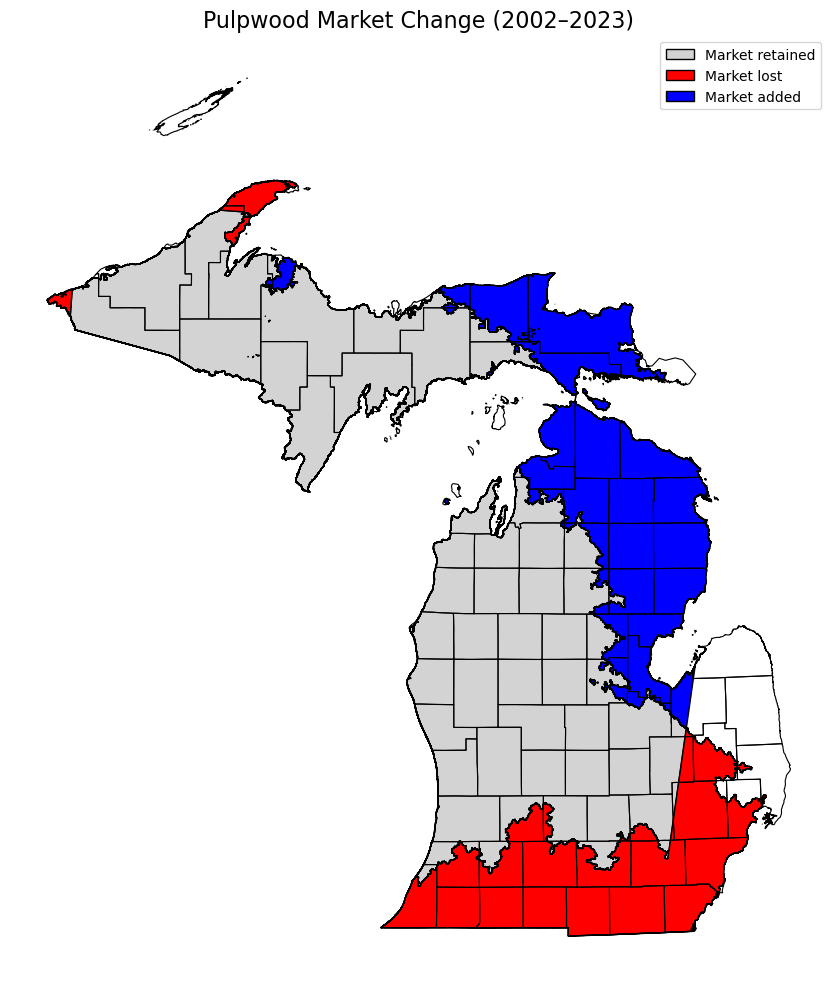

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_2002_fp = os.path.join(base_path, "pulpwood_coverage_2002.shp")
coverage_2023_fp = os.path.join(base_path, "pulpwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "pulpwood_change_2002-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_2002 = gpd.read_file(coverage_2002_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2002.crs)
if gdf_2002.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2002.crs)

# --- Geometry union ---
geom_2002 = gdf_2002.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types ---
retain = geom_2002.intersection(geom_2023)
loss = geom_2002.difference(geom_2023)
add = geom_2023.difference(geom_2002)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2002.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Pulpwood Market Change (2002–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\258390843.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2018 = gdf_2018.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\258390843.py:41: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\pulpwood_change_2018-2023.shp


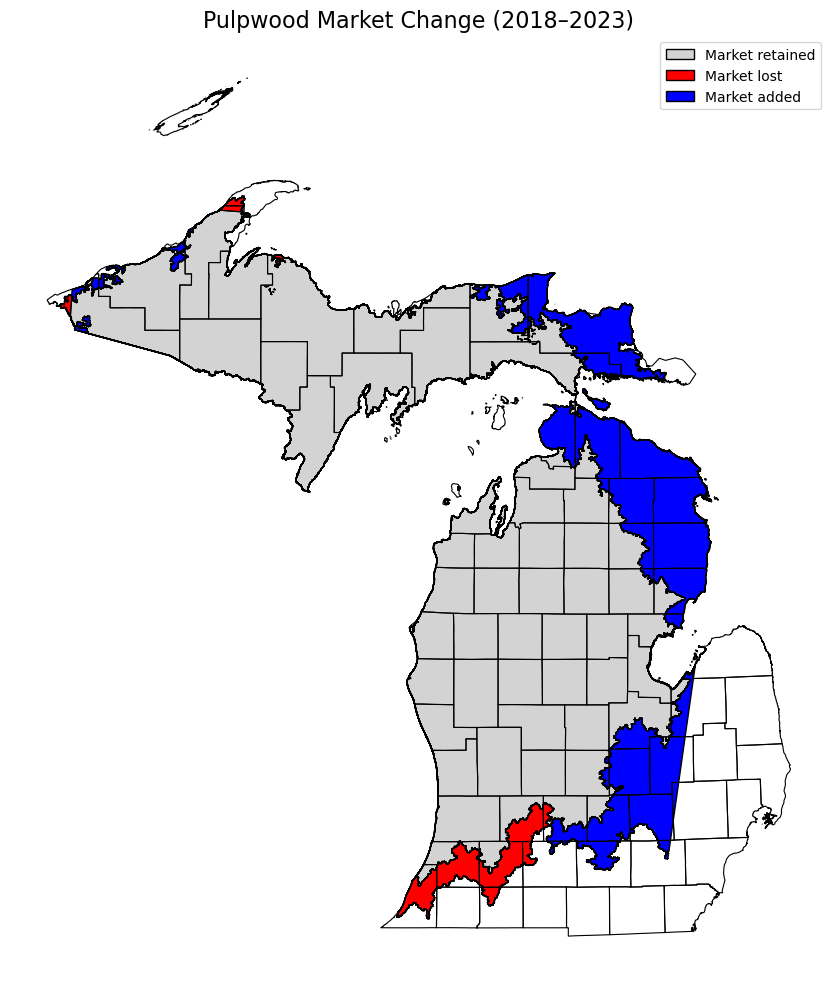

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
from shapely.geometry import GeometryCollection, MultiPolygon, Polygon

# --- Helper function to flatten geometries ---
def flatten_geometry(geom):
    if geom.is_empty:
        return None
    elif isinstance(geom, (Polygon, MultiPolygon)):
        return geom
    elif isinstance(geom, GeometryCollection):
        polys = [g for g in geom.geoms if isinstance(g, (Polygon, MultiPolygon))]
        if not polys:
            return None
        return MultiPolygon(polys) if len(polys) > 1 else polys[0]
    else:
        return None

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_2018_fp = os.path.join(base_path, "pulpwood_coverage_2018.shp")
coverage_2023_fp = os.path.join(base_path, "pulpwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "pulpwood_change_2018-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load data ---
gdf_2018 = gpd.read_file(coverage_2018_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2018.crs)
if gdf_2018.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2018.crs)

# --- Union geometries ---
geom_2018 = gdf_2018.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types and flatten ---
retain = flatten_geometry(geom_2018.intersection(geom_2023))
loss = flatten_geometry(geom_2018.difference(geom_2023))
add = flatten_geometry(geom_2023.difference(geom_2018))

# --- Assemble results ---
status_list = []
geometry_list = []

if retain: status_list.append("Market Retain"); geometry_list.append(retain)
if loss:   status_list.append("Market Loss");   geometry_list.append(loss)
if add:    status_list.append("Market Add");    geometry_list.append(add)

gdf_change = gpd.GeoDataFrame({
    "status": status_list,
    "geometry": geometry_list
}, crs=gdf_2018.crs)

# --- Save to shapefile ---
gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    subset = gdf_change[gdf_change["status"] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Pulpwood Market Change (2018–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


# Hardwood Sawlogs

c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Dissolved shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_coverage_1985.shp


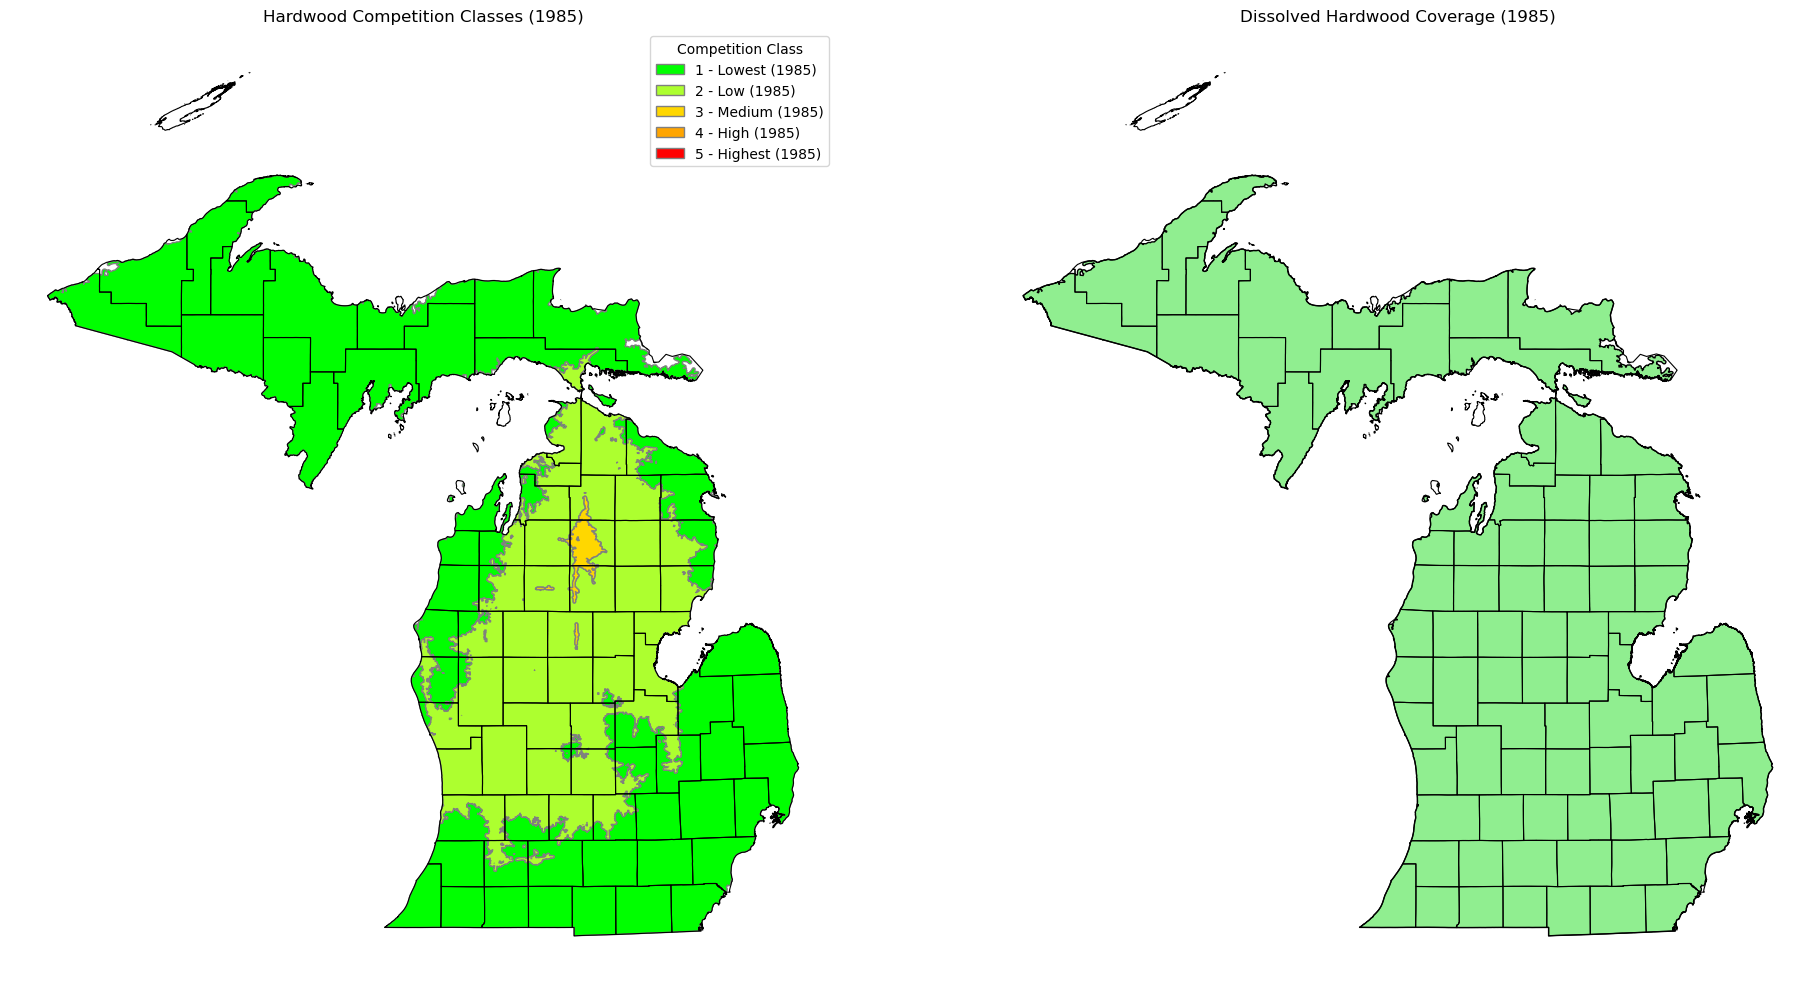

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
hardwood_1985_fp = os.path.join(base_path, "hardwood_hotspots_1985.shp")
dissolved_1985_fp = os.path.join(base_path, "hardwood_coverage_1985.shp")

# --- Load shapefiles ---
gdf_michigan = gpd.read_file(michigan_fp)
gdf_1985 = gpd.read_file(hardwood_1985_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_michigan.crs:
    gdf_1985 = gdf_1985.to_crs(gdf_michigan.crs)

# --- Dissolve polygons ---
gdf_union = gdf_1985.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1985_fp)
print("✅ Dissolved shapefile saved to:", dissolved_1985_fp)

# --- Reload dissolved layer ---
gdf_union = gpd.read_file(dissolved_1985_fp)

# --- Color map for 1985 ---
color_map = {
    "1 - Lowest (1985)": "#00FF00",
    "2 - Low (1985)": "#ADFF2F",
    "3 - Medium (1985)": "#FFD700",
    "4 - High (1985)": "#FFA500",
    "5 - Highest (1985)": "#FF0000"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original polygons
gdf_michigan.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_1985[gdf_1985["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Hardwood Competition Classes (1985)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_michigan.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Hardwood Coverage (1985)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_coverage_1994.shp


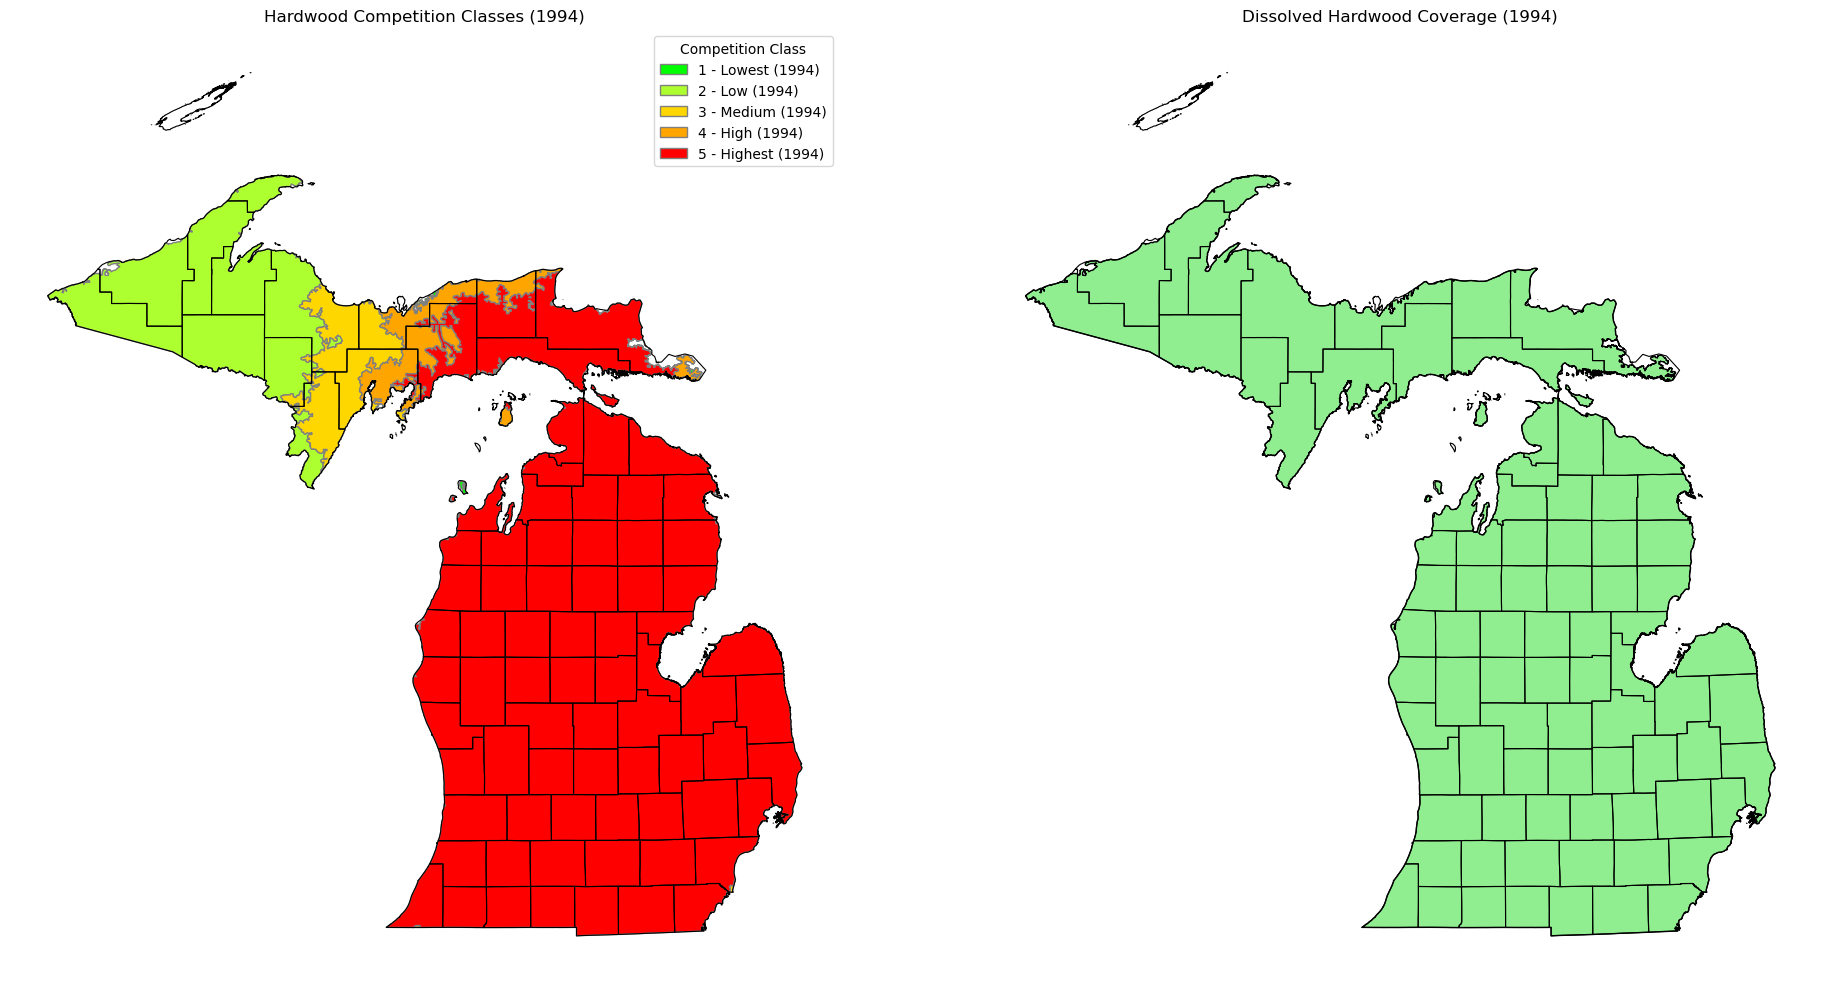

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
hardwood_1994_fp = os.path.join(base_path, "hardwood_hotspots_1994.shp")
dissolved_1994_fp = os.path.join(base_path, "hardwood_coverage_1994.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_1994 = gpd.read_file(hardwood_1994_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_mi.crs:
    gdf_1994 = gdf_1994.to_crs(gdf_mi.crs)

# --- Dissolve into single polygon ---
gdf_union = gdf_1994.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1994_fp)
print("✅ Saved dissolved shapefile to:", dissolved_1994_fp)

# --- Reload dissolved layer ---
gdf_union = gpd.read_file(dissolved_1994_fp)

# --- Color map for 1994 ---
color_map = {
    "1 - Lowest (1994)": "#00FF00",
    "2 - Low (1994)": "#ADFF2F",
    "3 - Medium (1994)": "#FFD700",
    "4 - High (1994)": "#FFA500",
    "5 - Highest (1994)": "#FF0000"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original polygons
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_1994[gdf_1994["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Hardwood Competition Classes (1994)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Hardwood Coverage (1994)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_coverage_2002.shp


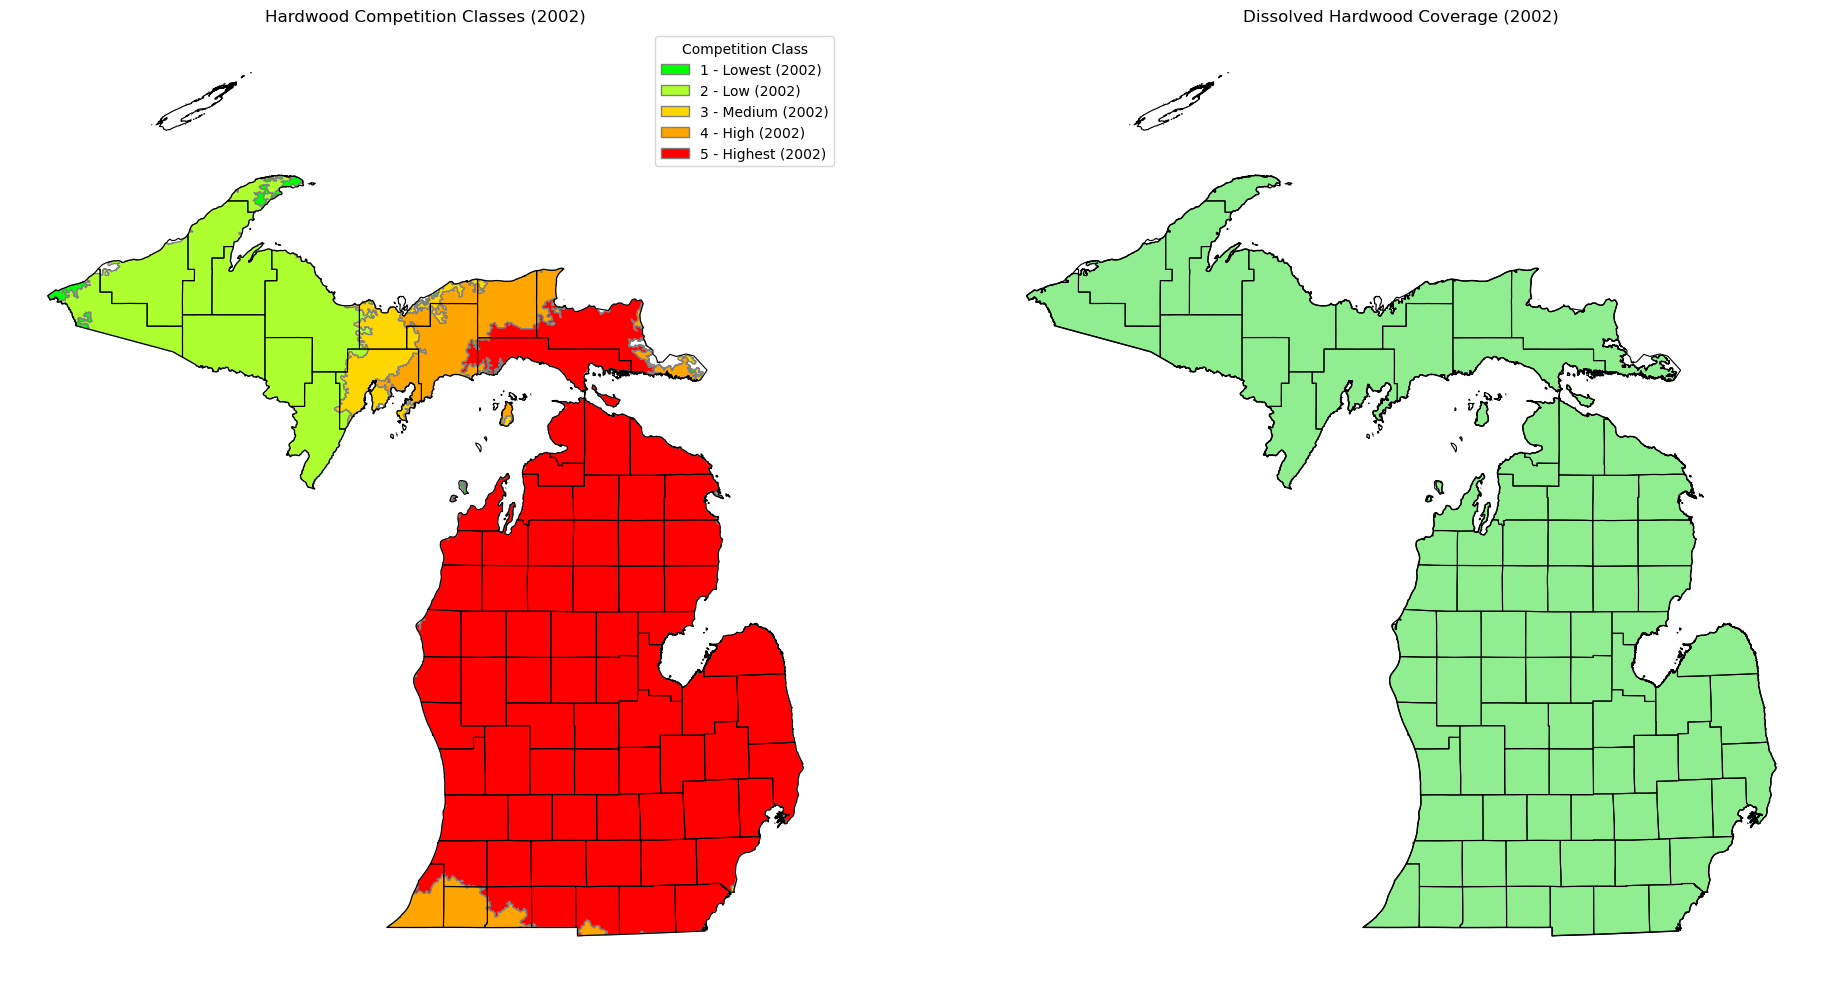

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
hardwood_2002_fp = os.path.join(base_path, "hardwood_hotspots_2002.shp")
dissolved_2002_fp = os.path.join(base_path, "hardwood_coverage_2002.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2002 = gpd.read_file(hardwood_2002_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_mi.crs:
    gdf_2002 = gdf_2002.to_crs(gdf_mi.crs)

# --- Dissolve all polygons into one ---
gdf_union = gdf_2002.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2002_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2002_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_2002_fp)

# --- Color map for competition classes ---
color_map = {
    "1 - Lowest (2002)": "#00FF00",
    "2 - Low (2002)": "#ADFF2F",
    "3 - Medium (2002)": "#FFD700",
    "4 - High (2002)": "#FFA500",
    "5 - Highest (2002)": "#FF0000"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition hotspots
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2002[gdf_2002["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Hardwood Competition Classes (2002)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Hardwood Coverage (2002)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_coverage_2018.shp


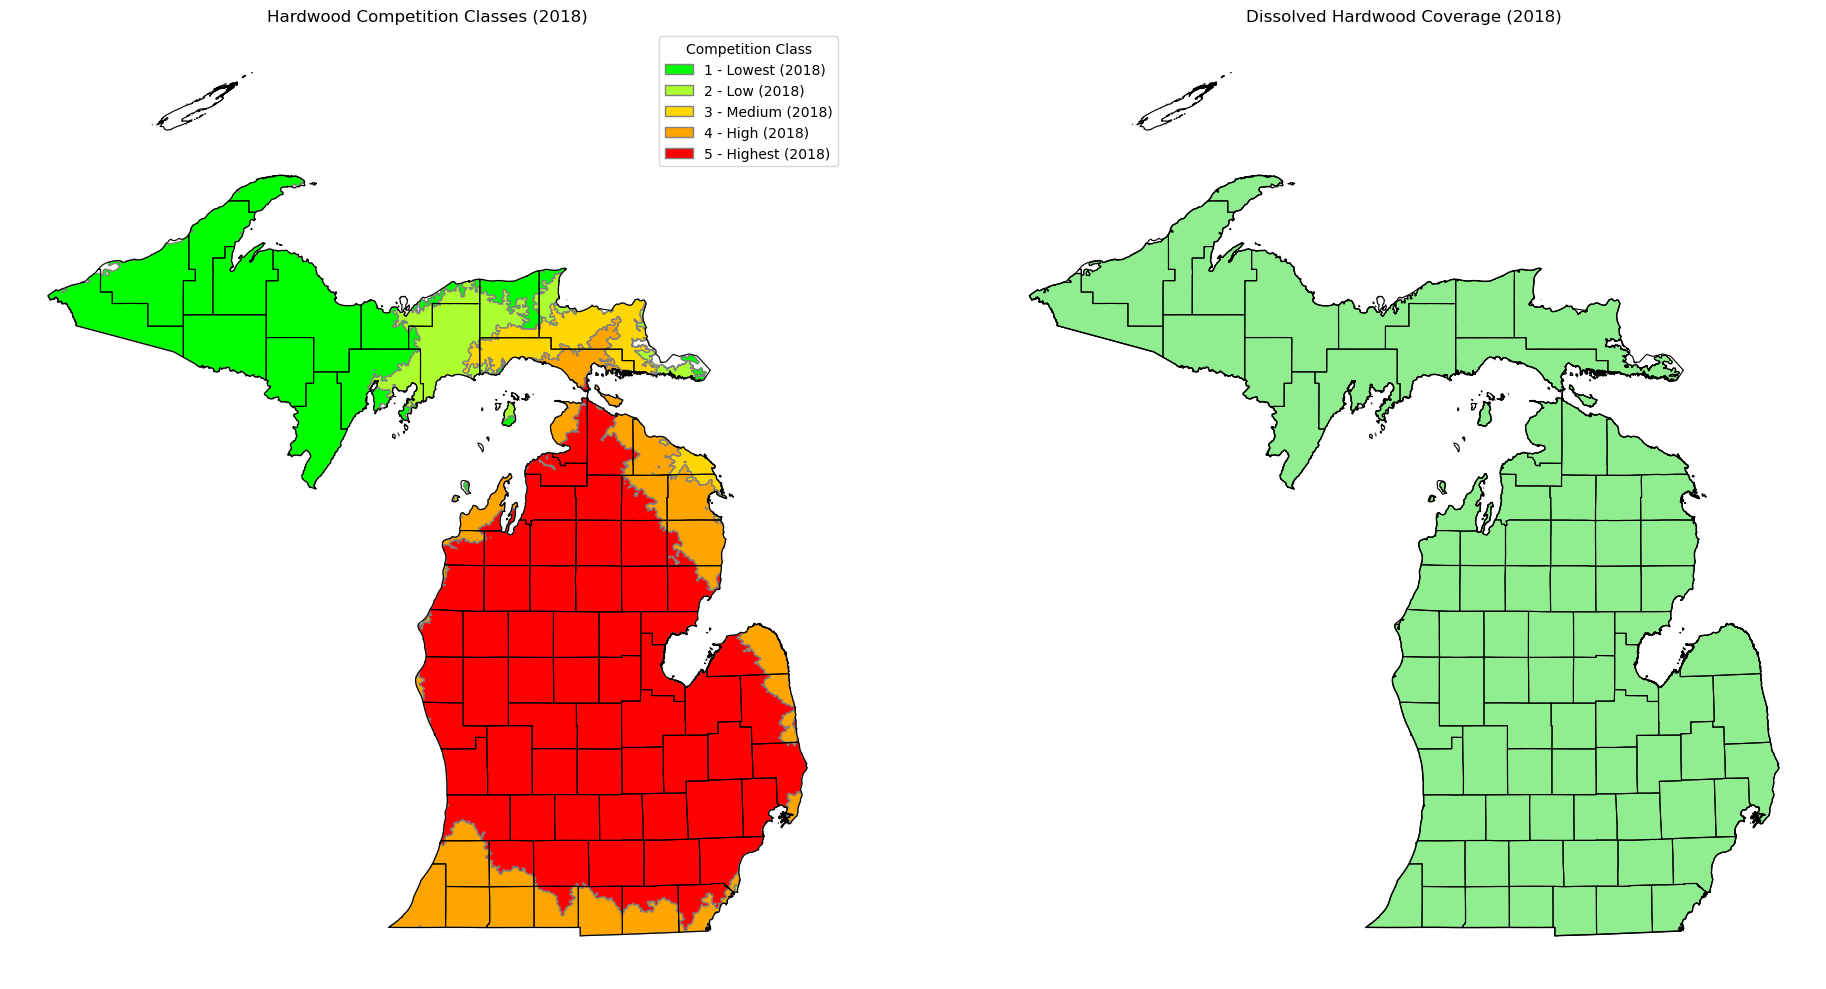

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
hardwood_2018_fp = os.path.join(base_path, "hardwood_hotspots_2018.shp")
dissolved_2018_fp = os.path.join(base_path, "hardwood_coverage_2018.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2018 = gpd.read_file(hardwood_2018_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_mi.crs:
    gdf_2018 = gdf_2018.to_crs(gdf_mi.crs)

# --- Dissolve all polygons into one ---
gdf_union = gdf_2018.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2018_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2018_fp)

# --- Reload dissolved file to confirm ---
gdf_union = gpd.read_file(dissolved_2018_fp)

# --- Color map for competition classes ---
color_map = {
    "1 - Lowest (2018)": "#00FF00",
    "2 - Low (2018)": "#ADFF2F",
    "3 - Medium (2018)": "#FFD700",
    "4 - High (2018)": "#FFA500",
    "5 - Highest (2018)": "#FF0000"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition hotspots
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2018[gdf_2018["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Hardwood Competition Classes (2018)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Hardwood Coverage (2018)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_coverage_2023.shp


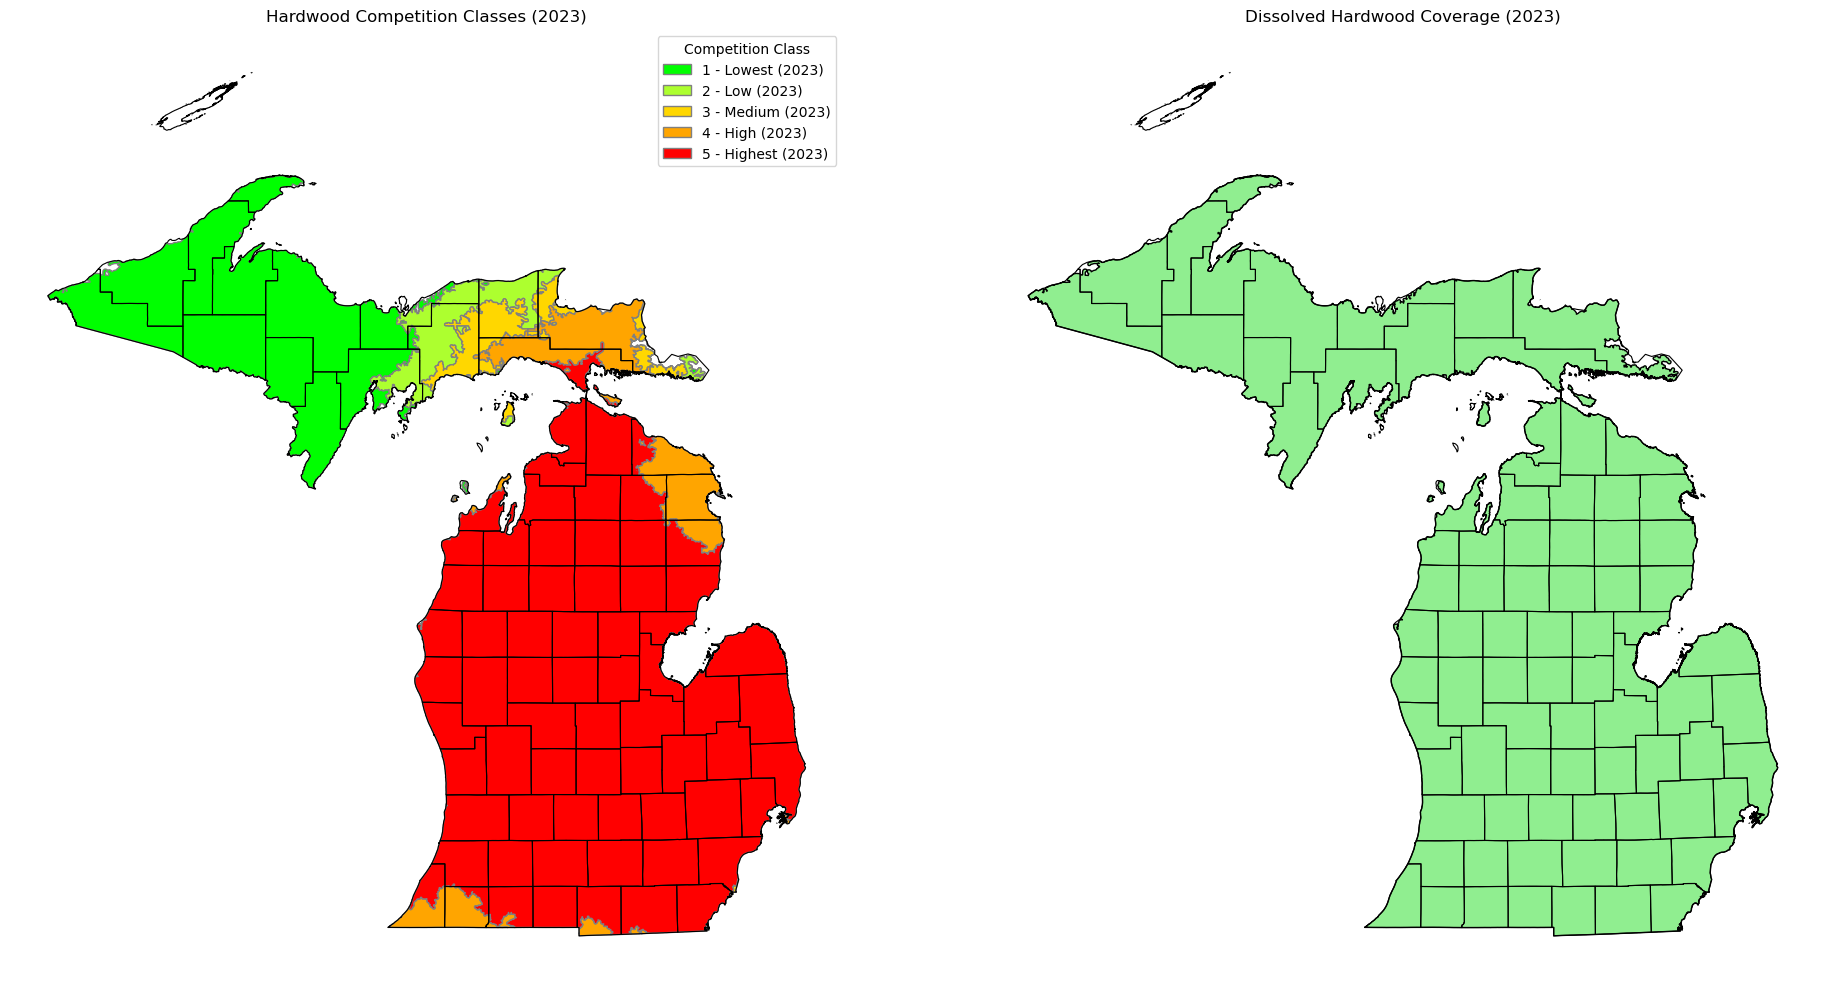

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
hardwood_2023_fp = os.path.join(base_path, "hardwood_hotspots_2023.shp")
dissolved_2023_fp = os.path.join(base_path, "hardwood_coverage_2023.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2023 = gpd.read_file(hardwood_2023_fp)

# --- Reproject if needed ---
if gdf_2023.crs != gdf_mi.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_2023.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2023_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2023_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_2023_fp)

# --- Color map for 2023 competition classes ---
color_map = {
    "1 - Lowest (2023)": "#00FF00",
    "2 - Low (2023)": "#ADFF2F",
    "3 - Medium (2023)": "#FFD700",
    "4 - High (2023)": "#FFA500",
    "5 - Highest (2023)": "#FF0000"
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2023[gdf_2023["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Hardwood Competition Classes (2023)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Hardwood Coverage (2023)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\214320967.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1985 = gdf_1985.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\214320967.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Saved change shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_change_1985-2023.shp


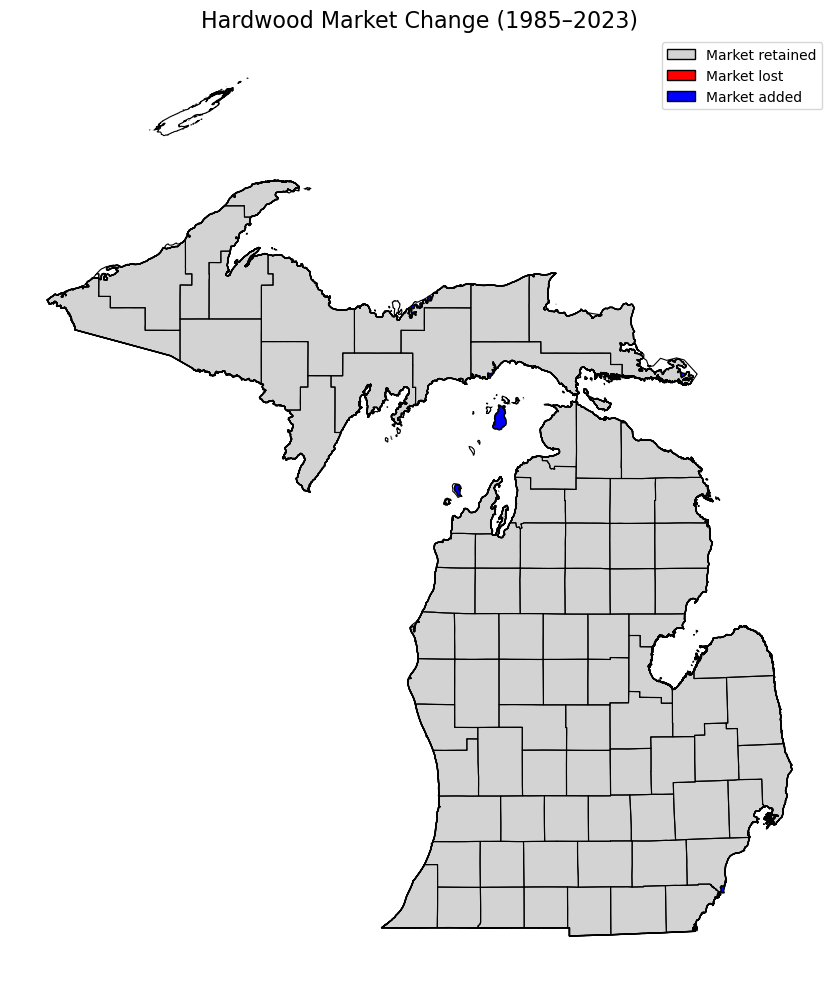

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1985_fp = os.path.join(base_path, "hardwood_coverage_1985.shp")
coverage_2023_fp = os.path.join(base_path, "hardwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "hardwood_change_1985-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load data ---
gdf_1985 = gpd.read_file(coverage_1985_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1985.crs)
if gdf_1985.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1985.crs)

# --- Geometry union ---
geom_1985 = gdf_1985.unary_union
geom_2023 = gdf_2023.unary_union

# --- Compute change classes ---
retain = geom_1985.intersection(geom_2023)
loss = geom_1985.difference(geom_2023)
add = geom_2023.difference(geom_1985)

# --- Save output shapefile ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1985.crs)

gdf_change.to_file(change_fp)
print("✅ Saved change shapefile to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Plot each change type
for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Hardwood Market Change (1985–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
import os
from pathlib import Path

# Recursively find all shapefiles under "Data"
shapefiles = list(Path("Khanal_MSc_Thesis_MSU-main").rglob("*.shp"))

print("📁 Available shapefiles:")
for shp in shapefiles:
    print(shp)


📁 Available shapefiles:


In [3]:
import rasterio
from rasterio.mask import mask
import fiona
import numpy as np
from shapely.geometry import shape, mapping
from shapely.ops import transform
import pyproj
import os

# ✅ File paths
base_path = "Data"
raster_path = os.path.join(base_path, "forest_cover_2019.tif")
shapefile_path = os.path.join(base_path, "hardwood_change_1985-2018.shp")  # ✅ Updated for hardwood 1985–2018

# ✅ Forest group code mapping
forest_type_mapping = {
    100: "White/Red/Jack Pine Group",
    120: "Spruce/Fir Group",
    140: "Longleaf/Slash Pine Group",
    160: "Loblolly/Shortleaf Pine Group",
    180: "Pinyon/Juniper Group",
    200: "Douglas-fir Group",
    220: "Ponderosa Pine Group",
    240: "Western White Pine Group",
    260: "Fir/Spruce/Mountain Hemlock Group",
    280: "Lodgepole Pine Group",
    300: "Hemlock/Sitka Spruce Group",
    320: "Western Larch Group",
    340: "Redwood Group",
    360: "Other Western Softwood Group",
    370: "California Mixed Conifer Group",
    380: "Exotic Softwoods Group",
    400: "Oak/Pine Group",
    500: "Oak/Hickory Group",
    600: "Oak/Gum/Cypress Group",
    700: "Elm/Ash/Cottonwood Group",
    800: "Maple/Beech/Birch Group",
    900: "Aspen/Birch Group",
    910: "Alder/Maple Group",
    920: "Western Oak Group",
    940: "Tanoak/Laurel Group",
    950: "Other Western Hardwoods Group",
    980: "Tropical Hardwoods Group",
    990: "Exotic Hardwoods Group"
}

# ✅ Raster and shapefile processing
with rasterio.open(raster_path) as src:
    pixel_area_acres = src.res[0] * abs(src.res[1]) * 0.000247105
    nodata = src.nodata
    raster_crs = src.crs

    with fiona.open(shapefile_path, 'r') as shapefile:
        shp_crs = shapefile.crs

        def reproject_geom(geom, src_crs, dst_crs):
            transformer = pyproj.Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform
            return mapping(transform(transformer, shape(geom)))

        for feature in shapefile:
            polygon_label = feature["properties"].get("status", "unknown")
            geom = feature["geometry"]

            if shp_crs != raster_crs:
                geom = reproject_geom(geom, shp_crs, raster_crs)

            try:
                out_image, _ = mask(src, [geom], crop=True)
            except ValueError:
                print(f"⚠️ Polygon '{polygon_label}' does not overlap the raster. Skipping...")
                continue

            data = out_image[0]
            valid_data = data[data != nodata] if nodata is not None else data

            unique_types, counts = np.unique(valid_data, return_counts=True)

            forest_type_areas = {
                forest_type_mapping.get(code): count * pixel_area_acres
                for code, count in zip(unique_types, counts)
                if forest_type_mapping.get(code)
            }

            total_area = sum(forest_type_areas.values())

            print(f"✅ Polygon '{polygon_label}' has total forest area: {total_area:,.2f} acres")
            for ft, area in forest_type_areas.items():
                print(f"   {ft}: {area:,.2f} acres")
            print()


DriverError: Failed to open dataset (flags=68): Data/hardwood_change_1985-2018.shp

C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\463110149.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1994 = gdf_1994.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\463110149.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Saved change shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_change_1994-2023.shp


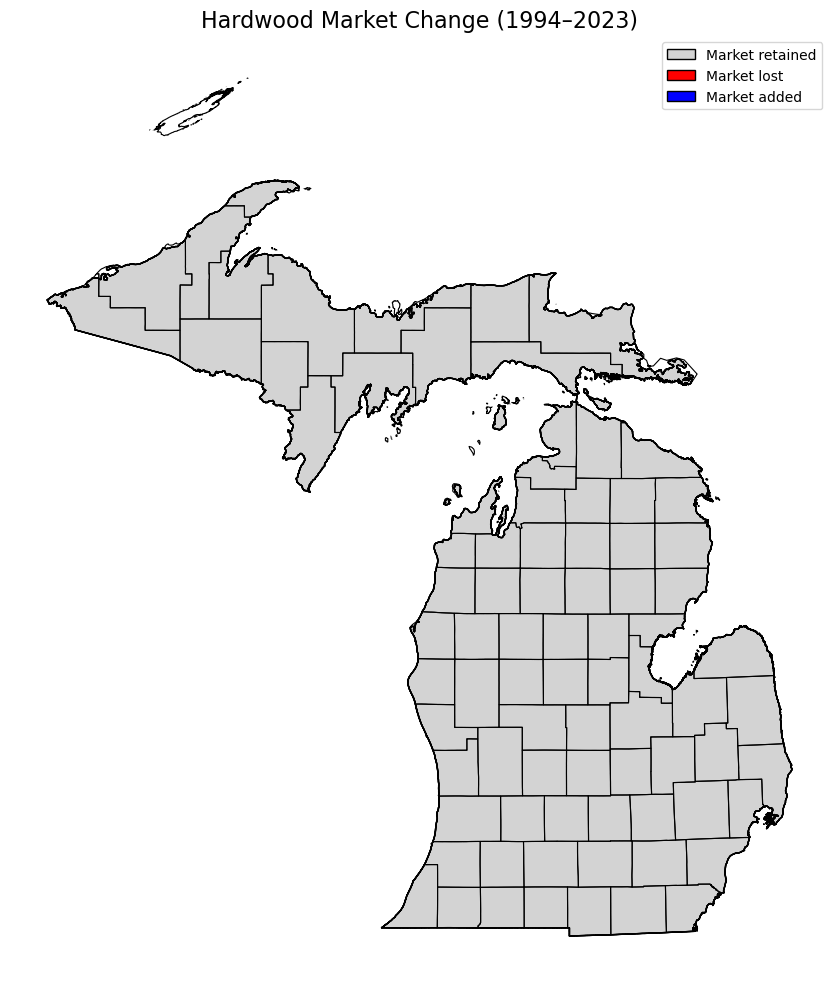

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1994_fp = os.path.join(base_path, "hardwood_coverage_1994.shp")
coverage_2023_fp = os.path.join(base_path, "hardwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "hardwood_change_1994-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load data ---
gdf_1994 = gpd.read_file(coverage_1994_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1994.crs)
if gdf_1994.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1994.crs)

# --- Geometry union ---
geom_1994 = gdf_1994.unary_union
geom_2023 = gdf_2023.unary_union

# --- Compute market change classes ---
retain = geom_1994.intersection(geom_2023)
loss = geom_1994.difference(geom_2023)
add = geom_2023.difference(geom_1994)

# --- Save change shapefile ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1994.crs)

gdf_change.to_file(change_fp)
print("✅ Saved change shapefile to:", change_fp)

# --- Color map ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Hardwood Market Change (1994–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\300229013.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2002 = gdf_2002.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\300229013.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Saved change shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_change_2002-2023.shp


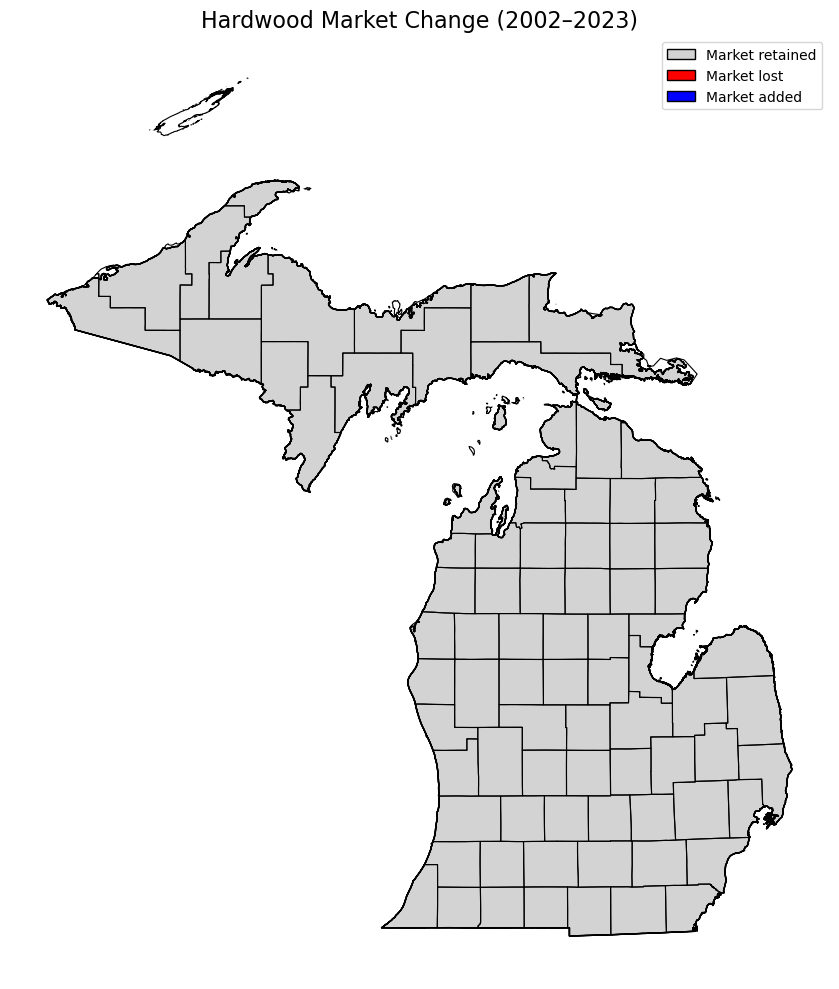

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_2002_fp = os.path.join(base_path, "hardwood_coverage_2002.shp")
coverage_2023_fp = os.path.join(base_path, "hardwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "hardwood_change_2002-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load shapefiles ---
gdf_2002 = gpd.read_file(coverage_2002_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2002.crs)
if gdf_2002.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2002.crs)

# --- Geometry union ---
geom_2002 = gdf_2002.unary_union
geom_2023 = gdf_2023.unary_union

# --- Compute change types ---
retain = geom_2002.intersection(geom_2023)
loss = geom_2002.difference(geom_2023)
add = geom_2023.difference(geom_2002)

# --- Build GeoDataFrame and save ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2002.crs)

gdf_change.to_file(change_fp)
print("✅ Saved change shapefile to:", change_fp)

# --- Color map ---
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Hardwood Market Change (2002–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\4292798287.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2018 = gdf_2018.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\4292798287.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Saved change shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\hardwood_change_2018-2023.shp


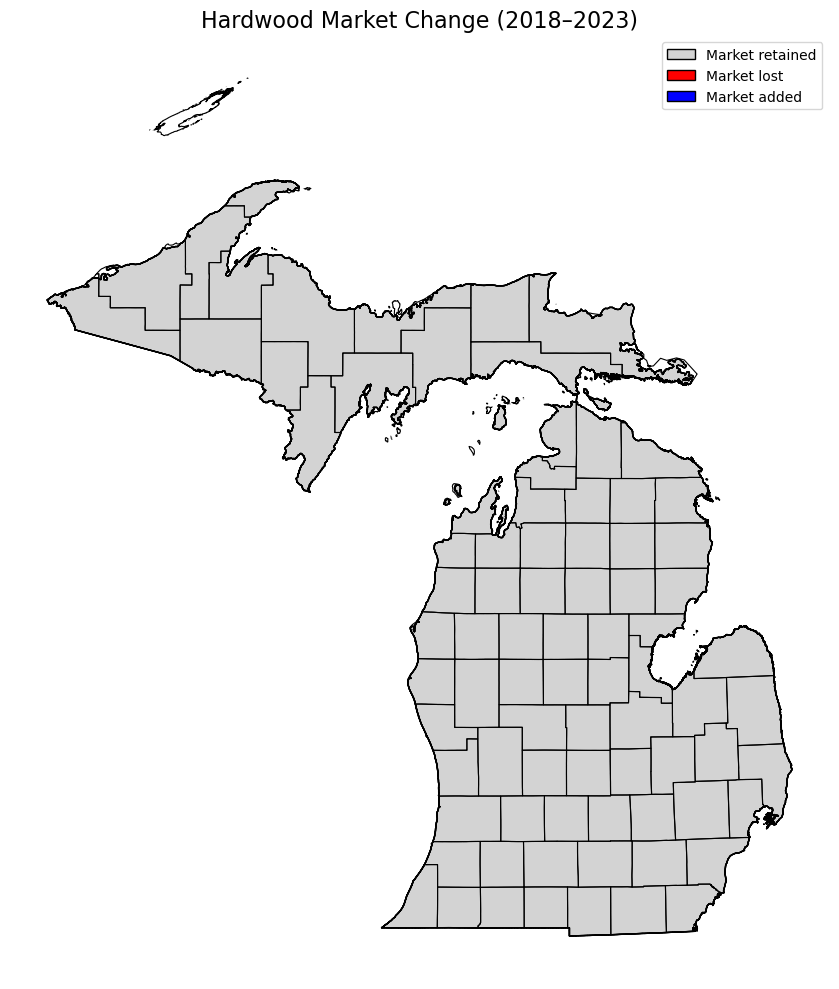

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_2018_fp = os.path.join(base_path, "hardwood_coverage_2018.shp")
coverage_2023_fp = os.path.join(base_path, "hardwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "hardwood_change_2018-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load shapefiles ---
gdf_2018 = gpd.read_file(coverage_2018_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2018.crs)
if gdf_2018.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2018.crs)

# --- Geometry union ---
geom_2018 = gdf_2018.unary_union
geom_2023 = gdf_2023.unary_union

# --- Compute change types ---
retain = geom_2018.intersection(geom_2023)
loss = geom_2018.difference(geom_2023)
add = geom_2023.difference(geom_2018)

# --- Build GeoDataFrame and save ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2018.crs)

gdf_change.to_file(change_fp)
print("✅ Saved change shapefile to:", change_fp)

# --- Color map ---
color_map = {
    "Market Retain": "#D3D3D3",
    "Market Loss": "#FF0000",
    "Market Add": "#0000FF"
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Hardwood Market Change (2018–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


# Softwood Sawlogs

c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_coverage_1985.shp


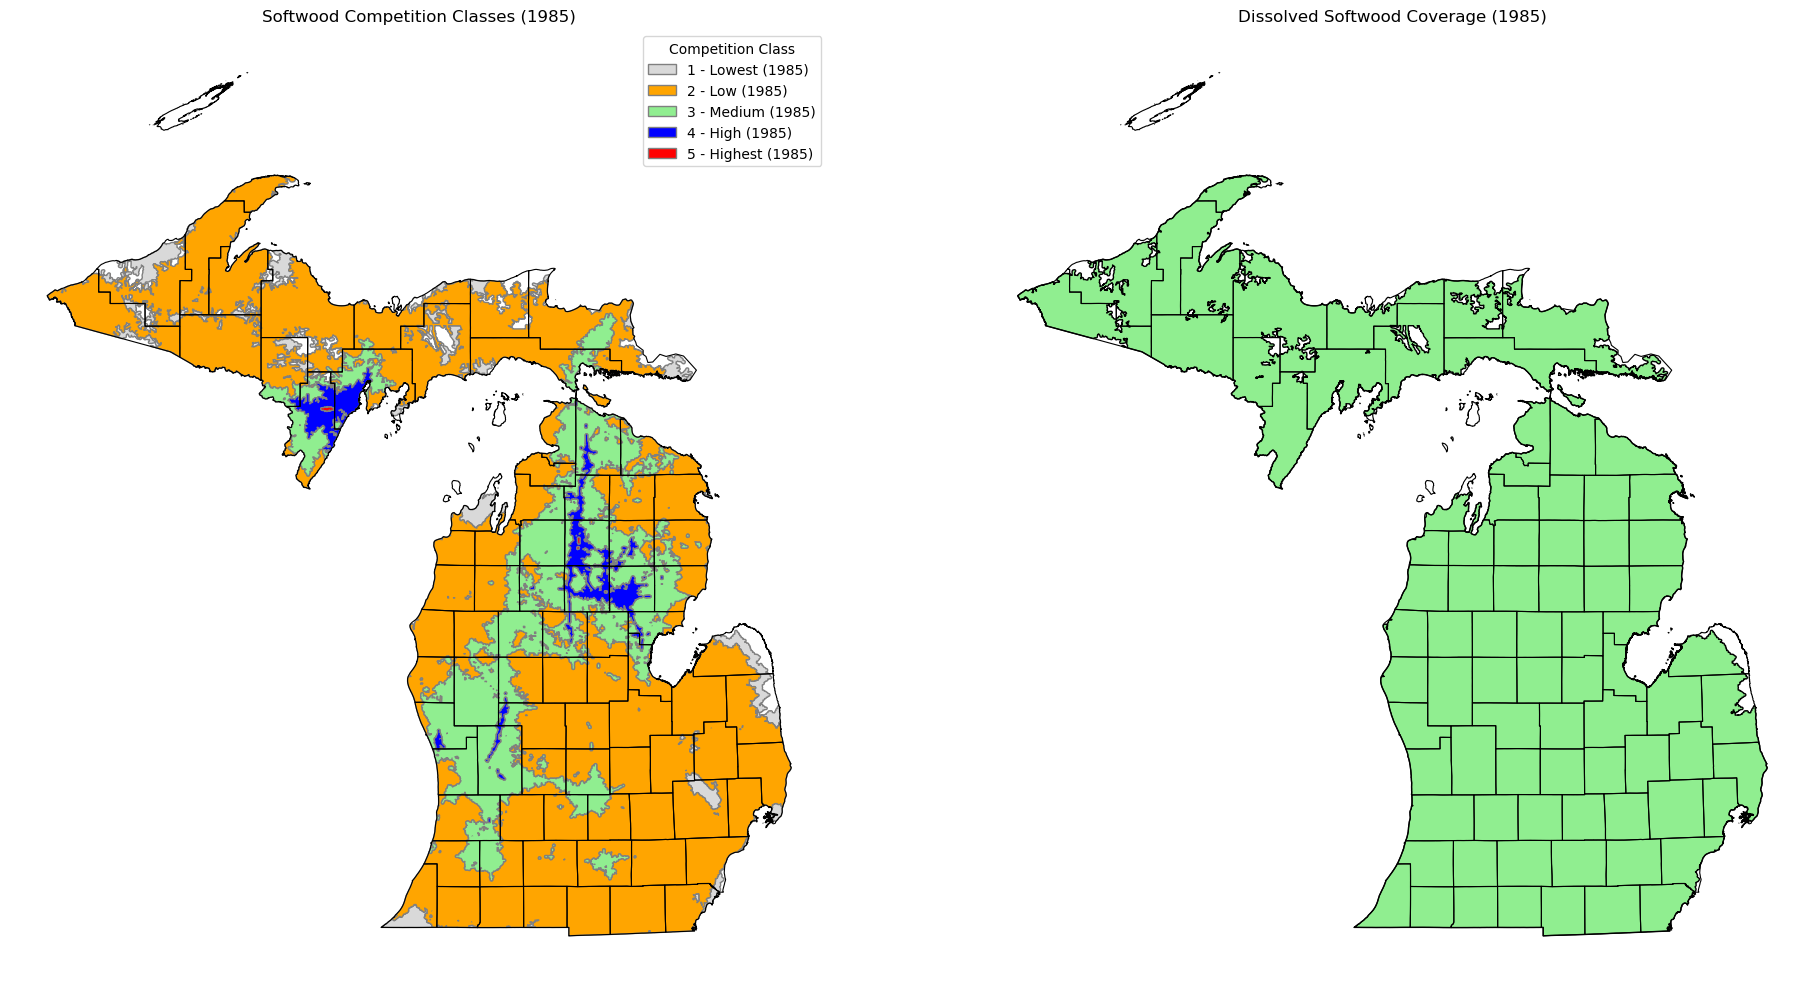

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
softwood_1985_fp = os.path.join(base_path, "softwood_hotspots_1985.shp")
dissolved_1985_fp = os.path.join(base_path, "softwood_coverage_1985.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_1985 = gpd.read_file(softwood_1985_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_mi.crs:
    gdf_1985 = gdf_1985.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_1985.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1985_fp)
print("✅ Saved dissolved shapefile to:", dissolved_1985_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_1985_fp)

# --- Color map for 1985 competition classes ---
color_map = {
    "1 - Lowest (1985)": "#D9D9D9",   # Light gray
    "2 - Low (1985)": "#FFA500",      # Orange
    "3 - Medium (1985)": "#90EE90",   # Light green
    "4 - High (1985)": "#0000FF",     # Blue
    "5 - Highest (1985)": "#FF0000"   # Red
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_1985[gdf_1985["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Softwood Competition Classes (1985)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Softwood Coverage (1985)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_coverage_1994.shp


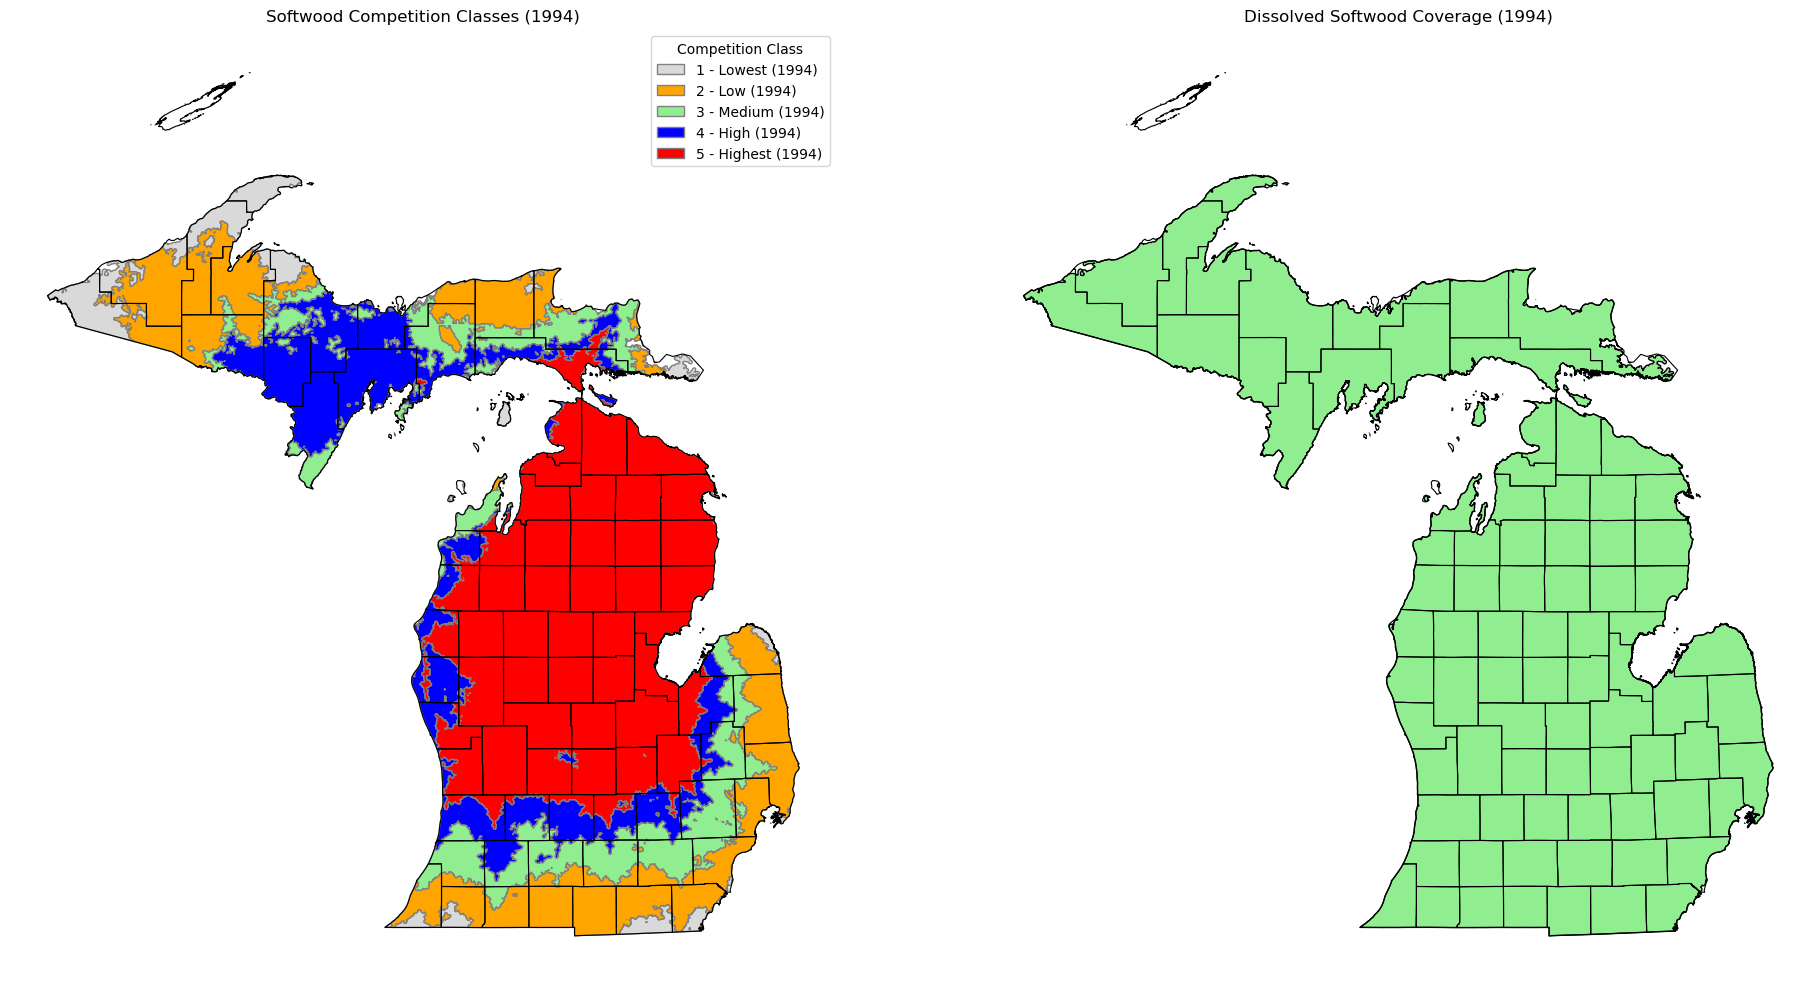

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
softwood_1994_fp = os.path.join(base_path, "softwood_hotspots_1994.shp")
dissolved_1994_fp = os.path.join(base_path, "softwood_coverage_1994.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_1994 = gpd.read_file(softwood_1994_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_mi.crs:
    gdf_1994 = gdf_1994.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_1994.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_1994_fp)
print("✅ Saved dissolved shapefile to:", dissolved_1994_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_1994_fp)

# --- Color map for 1994 competition classes ---
color_map = {
    "1 - Lowest (1994)": "#D9D9D9",   # Light gray
    "2 - Low (1994)": "#FFA500",      # Orange
    "3 - Medium (1994)": "#90EE90",   # Light green
    "4 - High (1994)": "#0000FF",     # Blue
    "5 - Highest (1994)": "#FF0000"   # Red
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_1994[gdf_1994["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Softwood Competition Classes (1994)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Softwood Coverage (1994)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_coverage_2002.shp


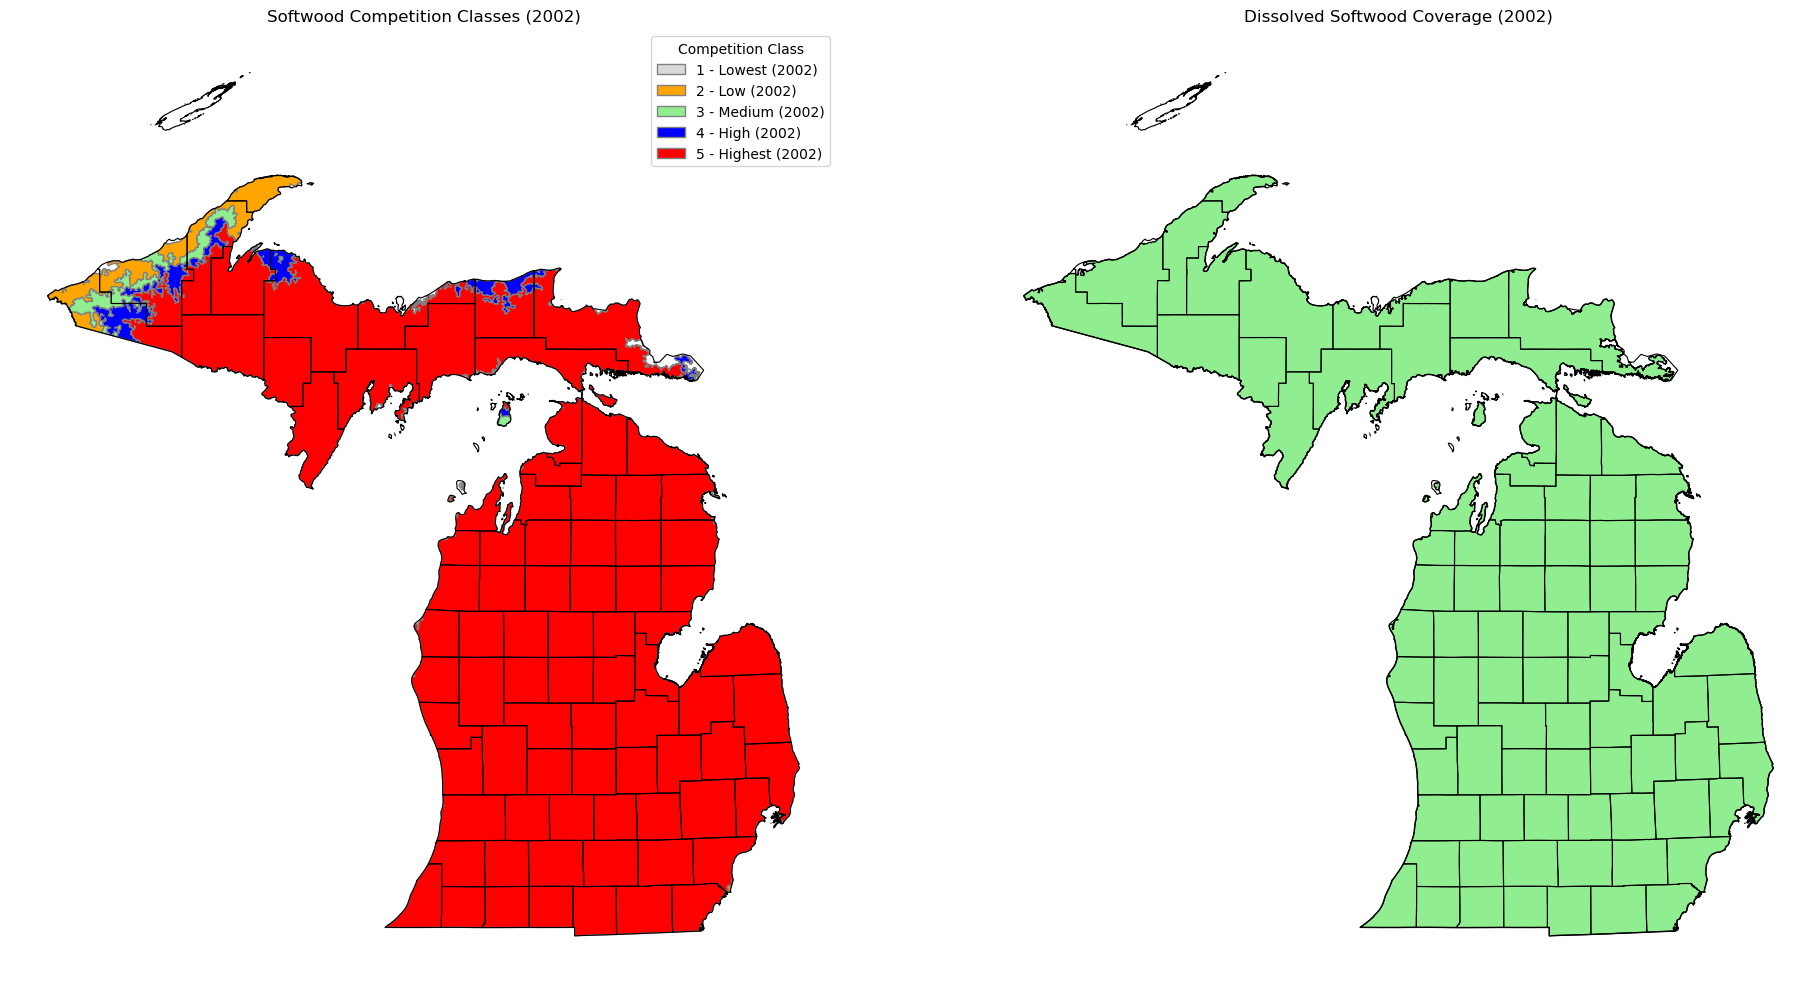

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
softwood_2002_fp = os.path.join(base_path, "softwood_hotspots_2002.shp")
dissolved_2002_fp = os.path.join(base_path, "softwood_coverage_2002.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2002 = gpd.read_file(softwood_2002_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_mi.crs:
    gdf_2002 = gdf_2002.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_2002.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2002_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2002_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_2002_fp)

# --- Color map for 2002 competition classes ---
color_map = {
    "1 - Lowest (2002)": "#D9D9D9",   # Light gray
    "2 - Low (2002)": "#FFA500",      # Orange
    "3 - Medium (2002)": "#90EE90",   # Light green
    "4 - High (2002)": "#0000FF",     # Blue
    "5 - Highest (2002)": "#FF0000"   # Red
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2002[gdf_2002["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Softwood Competition Classes (2002)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Softwood Coverage (2002)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


c:\Users\khanalna\AppData\Local\anaconda3\envs\colab_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'id' to 'id_1'
  ogr_write(


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_coverage_2018.shp


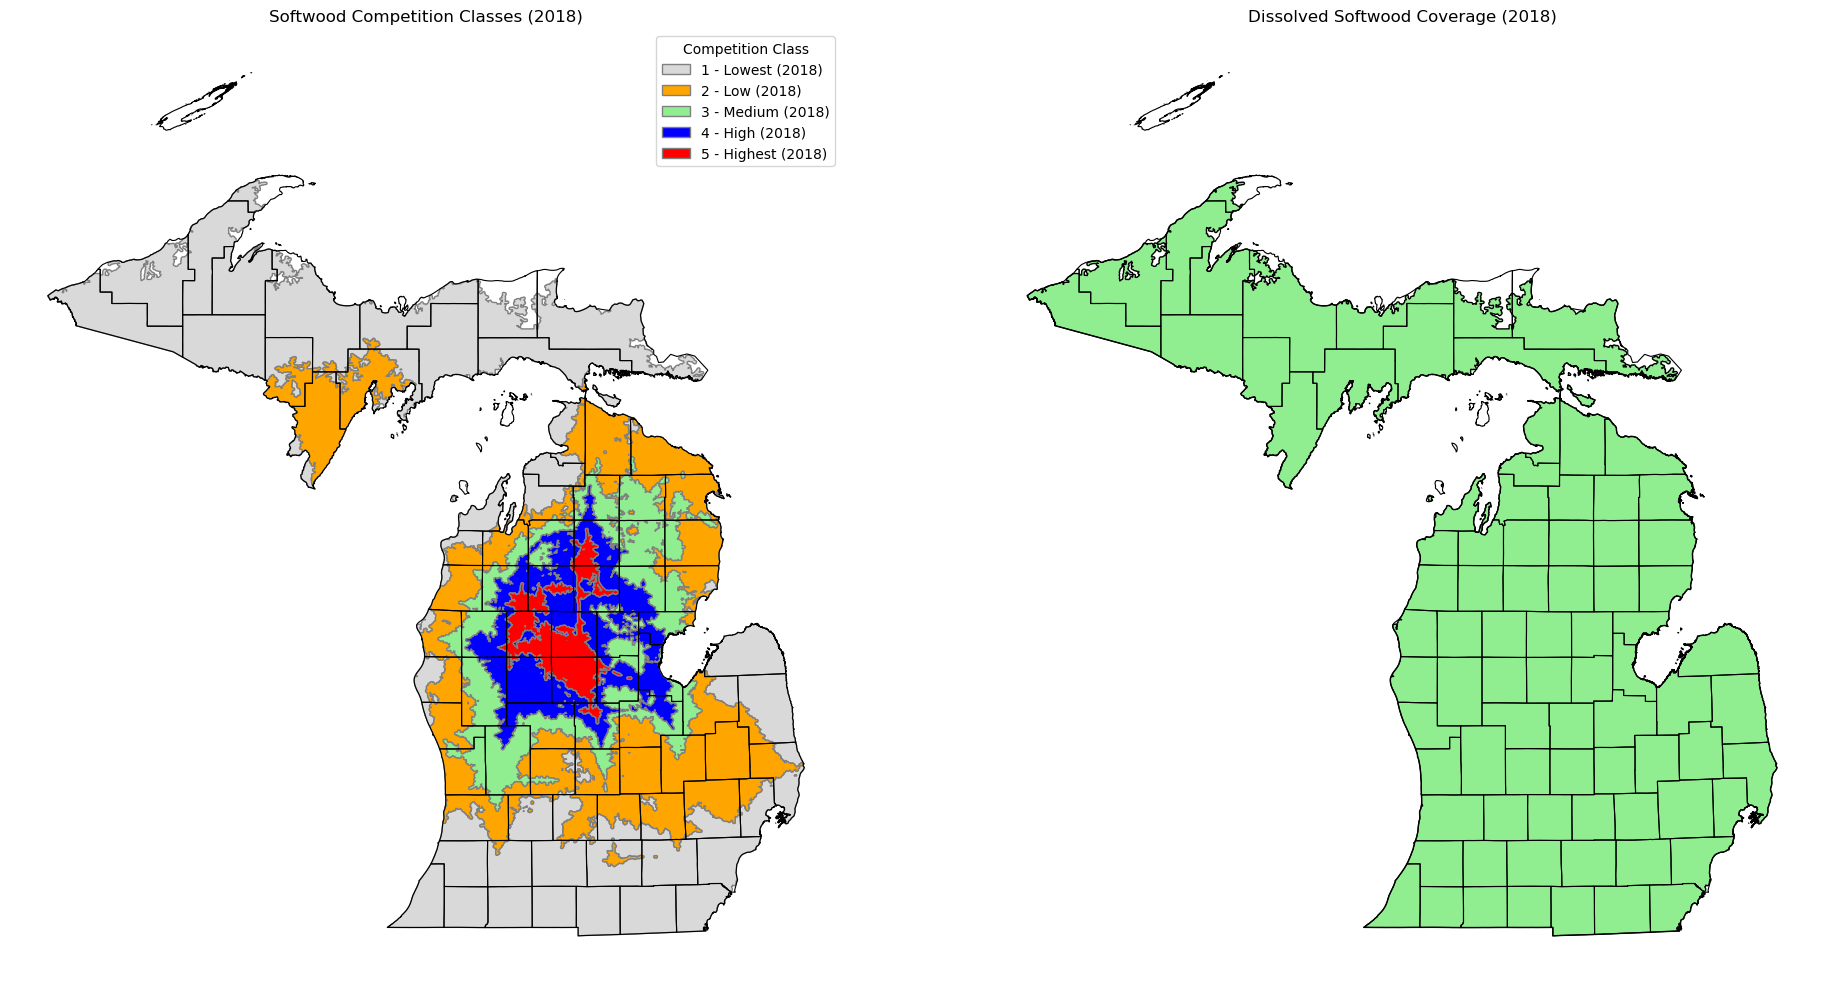

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
softwood_2018_fp = os.path.join(base_path, "softwood_hotspots_2018.shp")
dissolved_2018_fp = os.path.join(base_path, "softwood_coverage_2018.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2018 = gpd.read_file(softwood_2018_fp)

# --- Reproject if needed ---
if gdf_2018.crs != gdf_mi.crs:
    gdf_2018 = gdf_2018.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_2018.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2018_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2018_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_2018_fp)

# --- Color map for 2018 competition classes ---
color_map = {
    "1 - Lowest (2018)": "#D9D9D9",   # Light gray
    "2 - Low (2018)": "#FFA500",      # Orange
    "3 - Medium (2018)": "#90EE90",   # Light green
    "4 - High (2018)": "#0000FF",     # Blue
    "5 - Highest (2018)": "#FF0000"   # Red
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2018[gdf_2018["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Softwood Competition Classes (2018)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Softwood Coverage (2018)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


✅ Saved dissolved shapefile to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_coverage_2023.shp


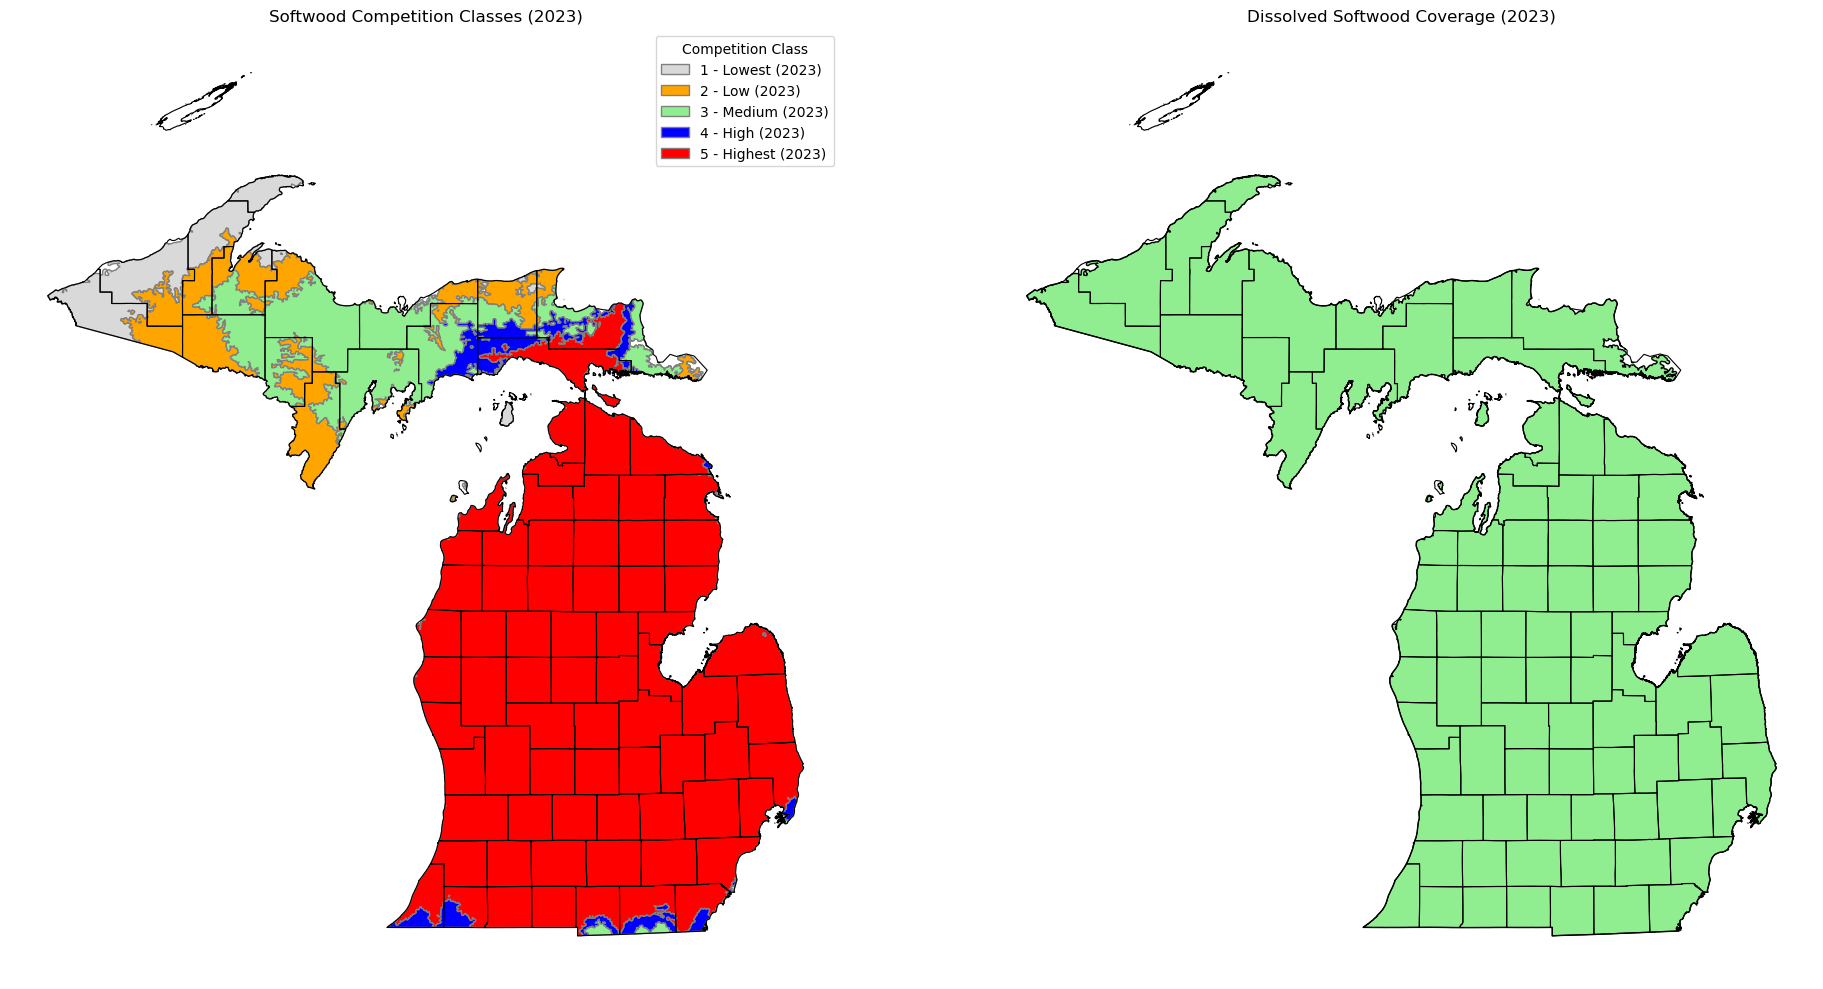

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- File paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")
softwood_2023_fp = os.path.join(base_path, "softwood_hotspots_2023.shp")
dissolved_2023_fp = os.path.join(base_path, "softwood_coverage_2023.shp")

# --- Load shapefiles ---
gdf_mi = gpd.read_file(michigan_fp)
gdf_2023 = gpd.read_file(softwood_2023_fp)

# --- Reproject if needed ---
if gdf_2023.crs != gdf_mi.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_mi.crs)

# --- Dissolve polygons ---
gdf_union = gdf_2023.dissolve().reset_index(drop=True)
gdf_union["id"] = 1
gdf_union.to_file(dissolved_2023_fp)
print("✅ Saved dissolved shapefile to:", dissolved_2023_fp)

# --- Reload dissolved shapefile ---
gdf_union = gpd.read_file(dissolved_2023_fp)

# --- Color map for 2023 competition classes ---
color_map = {
    "1 - Lowest (2023)": "#D9D9D9",   # Light gray
    "2 - Low (2023)": "#FFA500",      # Orange
    "3 - Medium (2023)": "#90EE90",   # Light green
    "4 - High (2023)": "#0000FF",     # Blue
    "5 - Highest (2023)": "#FF0000"   # Red
}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: Original competition classes
gdf_mi.boundary.plot(ax=axes[0], color='black', linewidth=0.8)
for label, color in color_map.items():
    subset = gdf_2023[gdf_2023["label"] == label]
    if not subset.empty:
        subset.plot(ax=axes[0], color=color, edgecolor='grey')

legend_elements = [
    Patch(facecolor=color, edgecolor='grey', label=label)
    for label, color in color_map.items()
]
axes[0].legend(handles=legend_elements, title="Competition Class", loc='upper right')
axes[0].set_title("Softwood Competition Classes (2023)")
axes[0].axis("off")

# Right: Dissolved polygon
gdf_mi.boundary.plot(ax=axes[1], color='black', linewidth=0.8)
gdf_union.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Dissolved Softwood Coverage (2023)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1840051743.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1985 = gdf_1985.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1840051743.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_change_1985-2023.shp


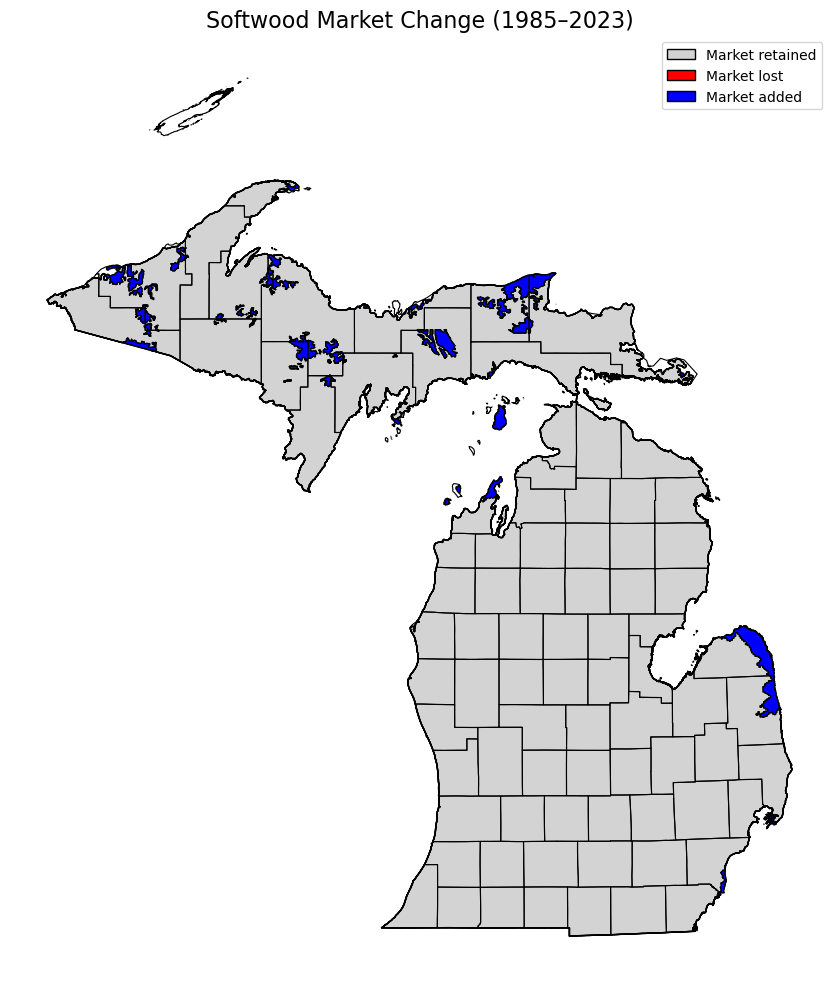

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1985_fp = os.path.join(base_path, "softwood_coverage_1985.shp")
coverage_2023_fp = os.path.join(base_path, "softwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "softwood_change_1985-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_1985 = gpd.read_file(coverage_1985_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1985.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1985.crs)
if gdf_1985.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1985.crs)

# --- Geometry union ---
geom_1985 = gdf_1985.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types ---
retain = geom_1985.intersection(geom_2023)
loss = geom_1985.difference(geom_2023)
add = geom_2023.difference(geom_1985)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1985.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Softwood Market Change (1985–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1912912438.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_1994 = gdf_1994.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\1912912438.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_change_1994-2023.shp


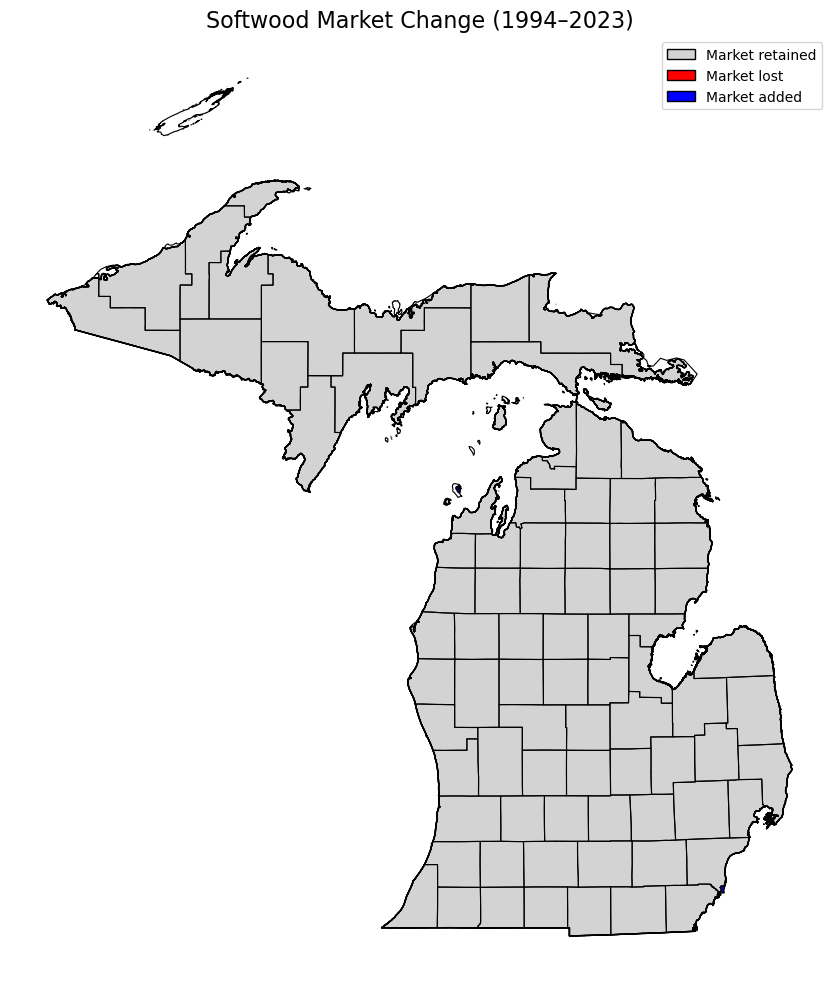

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_1994_fp = os.path.join(base_path, "softwood_coverage_1994.shp")
coverage_2023_fp = os.path.join(base_path, "softwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "softwood_change_1994-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_1994 = gpd.read_file(coverage_1994_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_1994.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_1994.crs)
if gdf_1994.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_1994.crs)

# --- Geometry union ---
geom_1994 = gdf_1994.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types ---
retain = geom_1994.intersection(geom_2023)
loss = geom_1994.difference(geom_2023)
add = geom_2023.difference(geom_1994)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_1994.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Softwood Market Change (1994–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\297714800.py:25: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2002 = gdf_2002.unary_union
C:\Users\khanalna\AppData\Local\Temp\ipykernel_21104\297714800.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_2023 = gdf_2023.unary_union


✅ Shapefile saved to: C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data\softwood_change_2002-2023.shp


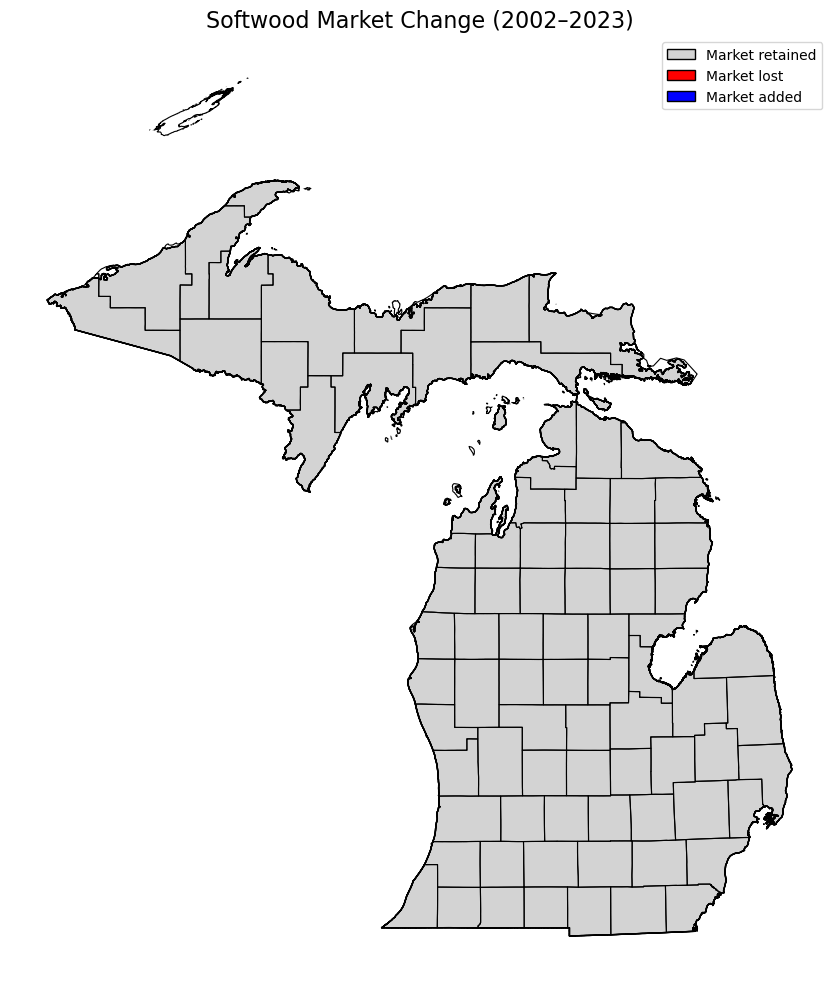

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Paths ---
base_path = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\June 25\Hotspots disolved July 27\Data"
coverage_2002_fp = os.path.join(base_path, "softwood_coverage_2002.shp")
coverage_2023_fp = os.path.join(base_path, "softwood_coverage_2023.shp")
change_fp = os.path.join(base_path, "softwood_change_2002-2023.shp")
michigan_fp = os.path.join(base_path, "Counties_(v17a).shp")

# --- Load input data ---
gdf_2002 = gpd.read_file(coverage_2002_fp)
gdf_2023 = gpd.read_file(coverage_2023_fp)
gdf_mi = gpd.read_file(michigan_fp)

# --- Reproject if needed ---
if gdf_2002.crs != gdf_2023.crs:
    gdf_2023 = gdf_2023.to_crs(gdf_2002.crs)
if gdf_2002.crs != gdf_mi.crs:
    gdf_mi = gdf_mi.to_crs(gdf_2002.crs)

# --- Geometry union ---
geom_2002 = gdf_2002.unary_union
geom_2023 = gdf_2023.unary_union

# --- Calculate change types ---
retain = geom_2002.intersection(geom_2023)
loss = geom_2002.difference(geom_2023)
add = geom_2023.difference(geom_2002)

# --- Build and save GeoDataFrame ---
gdf_change = gpd.GeoDataFrame({
    "status": ["Market Retain", "Market Loss", "Market Add"],
    "geometry": [retain, loss, add]
}, crs=gdf_2002.crs)

gdf_change.to_file(change_fp)
print("✅ Shapefile saved to:", change_fp)

# --- Color mapping ---
color_map = {
    "Market Retain": "#D3D3D3",  # Light gray
    "Market Loss": "#FF0000",    # Red
    "Market Add": "#0000FF"      # Blue
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))
gdf_mi.boundary.plot(ax=ax, color='black', linewidth=0.8)

for status, color in color_map.items():
    gdf_change[gdf_change["status"] == status].plot(ax=ax, color=color, edgecolor='black')

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map["Market Retain"], edgecolor='black', label="Market retained"),
    Patch(facecolor=color_map["Market Loss"], edgecolor='black', label="Market lost"),
    Patch(facecolor=color_map["Market Add"], edgecolor='black', label="Market added")
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.set_title("Softwood Market Change (2002–2023)", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()
